<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Multi-Target/MultiTarget_XAI_Hybrid_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q --upgrade \
    numpy==1.26.4 \
    scipy==1.14.1 \
    pandas==2.2.3 \
    numba==0.60.0 \
    llvmlite==0.43.0 \
    shap==0.46.0 \
    scikit-learn==1.5.2 \
    river==0.22.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
opencv-contrib-pyth

In [1]:
%pip install -q --upgrade river shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 84.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.66.0 which is incompatible.


In [1]:
import sys
import numpy as np
import pandas as pd
import scipy
import sklearn
import shap
import river

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SHAP:", shap.__version__)
print("River:", river.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.4.6
Pandas: 2.2.2
SciPy: 1.16.3
Scikit-learn: 1.6.1
SHAP: 0.52.0
River: 0.25.0


In [2]:
from river import compose
from river import preprocessing
from river import metrics
from river import forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("All required imports are working.")

All required imports are working.


In [3]:
from river import forest

test_model = forest.ARFRegressor(
    n_models=3,
    seed=42
)

print(test_model)
print("ARFRegressor is working.")

ARFRegressor
ARFRegressor is working.


In [5]:
import os
import re
import gc
import pickle
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from river import forest
from river import metrics

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All required imports are working.")

All required imports are working.


In [7]:
from google.colab import drive
# Change only this dataset path
DATA_PATH = (
    "/content/drive/MyDrive/"
    "Research v2/Research 18.03.2026/Multi Target/"
    "cleaned_multi_target_dataset (1).csv"
)

# All models and XAI results will be saved here
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Multi_Target_Hybrid_XAI"
)

MODEL_DIR = PROJECT_DIR / "saved_models"
OUTPUT_DIR = PROJECT_DIR / "xai_outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# True = train the River models
# False = load previously saved models
RETRAIN_HYBRID = True

# Smaller values make the XAI process faster
SURROGATE_SAMPLE_SIZE = 8000
PERMUTATION_SAMPLE_SIZE = 3000
SHAP_SAMPLE_SIZE = 500

print("Dataset path:", DATA_PATH)
print("Model folder:", MODEL_DIR)
print("Output folder:", OUTPUT_DIR)

Dataset path: /content/drive/MyDrive/Research v2/Research 18.03.2026/Multi Target/cleaned_multi_target_dataset (1).csv
Model folder: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/saved_models
Output folder: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/xai_outputs


In [8]:
RETRAIN_HYBRID = True

In [9]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset was not found:\n{DATA_PATH}\n\n"
        "Check the Google Drive path."
    )

multi_target_df = pd.read_csv(DATA_PATH)

print("Original dataset shape:", multi_target_df.shape)
display(multi_target_df.head())

Original dataset shape: (130003, 18)


,visibility_km,last_updated_epoch,air_quality_Ozone,latitude,air_quality_PM10,condition_text,air_quality_Sulphur_dioxide,uv_index,air_quality_Nitrogen_dioxide,feels_like_celsius,precip_mm,cloud,pressure_mb,longitude,air_quality_Carbon_Monoxide,air_quality_PM2.5,temperature_celsius,humidity
0,16.0,1715849100,62.2,46.60,7.1,2,0.2,1.0,2.5,16.1,0.00,0,1012.0,-120.49,198.6,6.3,16.1,58
1,10.0,1715849100,23.3,14.10,25.3,32,1.4,1.0,3.7,25.3,0.28,37,1017.0,-87.22,377.2,19.0,23.0,78
2,10.0,1715849100,5.9,13.71,28.1,23,7.5,1.0,7.7,30.2,0.30,50,1010.0,-89.20,460.6,20.4,26.0,94
3,5.0,1715849100,0.4,14.62,178.1,19,19.3,1.0,35.0,20.0,0.09,100,1019.0,-90.53,2243.0,132.0,20.0,88
4,10.0,1715849100,34.0,17.25,32.1,30,0.2,1.0,0.3,29.6,0.00,94,1007.0,-88.77,307.1,7.7,26.0,89


In [10]:
targets = [
    "air_quality_PM2.5",
    "temperature_celsius",
    "humidity"
]

missing_targets = [
    target
    for target in targets
    if target not in multi_target_df.columns
]

if missing_targets:
    raise ValueError(
        f"These target columns are missing: {missing_targets}"
    )

print("Targets:")
for target in targets:
    print("-", target)

Targets:
- air_quality_PM2.5
- temperature_celsius
- humidity


In [11]:
# Display non-numeric columns
non_numeric_columns = multi_target_df.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("Non-numeric columns:", non_numeric_columns)

Non-numeric columns: []


In [12]:
# Convert non-numeric feature columns to numeric codes
for column in non_numeric_columns:
    if column not in targets:
        multi_target_df[column], _ = pd.factorize(
            multi_target_df[column].astype(str)
        )

# Ensure targets are numeric
for target in targets:
    multi_target_df[target] = pd.to_numeric(
        multi_target_df[target],
        errors="coerce"
    )

print("Non-numeric columns converted.")

Non-numeric columns converted.


In [13]:
for target in targets:
    multi_target_df[f"{target}_lag1"] = (
        multi_target_df[target].shift(1)
    )

    multi_target_df[f"{target}_lag2"] = (
        multi_target_df[target].shift(2)
    )

print("Lag features created:")
for target in targets:
    print(f"- {target}_lag1")
    print(f"- {target}_lag2")

Lag features created:
- air_quality_PM2.5_lag1
- air_quality_PM2.5_lag2
- temperature_celsius_lag1
- temperature_celsius_lag2
- humidity_lag1
- humidity_lag2


In [14]:
multi_target_df = (
    multi_target_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

features = [
    column
    for column in multi_target_df.columns
    if column not in targets
]

# Make sure every feature is numeric
for feature in features:
    multi_target_df[feature] = pd.to_numeric(
        multi_target_df[feature],
        errors="coerce"
    )

multi_target_df = (
    multi_target_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("Cleaned dataset shape:", multi_target_df.shape)
print("Number of features:", len(features))
print("Number of targets:", len(targets))

Cleaned dataset shape: (130001, 24)
Number of features: 21
Number of targets: 3


In [15]:
print("Features used by the hybrid model:")

for number, feature in enumerate(features, start=1):
    print(number, feature)

Features used by the hybrid model:
1 visibility_km
2 last_updated_epoch
3 air_quality_Ozone
4 latitude
5 air_quality_PM10
6 condition_text
7 air_quality_Sulphur_dioxide
8 uv_index
9 air_quality_Nitrogen_dioxide
10 feels_like_celsius
11 precip_mm
12 cloud
13 pressure_mb
14 longitude
15 air_quality_Carbon_Monoxide
16 air_quality_PM2.5_lag1
17 air_quality_PM2.5_lag2
18 temperature_celsius_lag1
19 temperature_celsius_lag2
20 humidity_lag1
21 humidity_lag2


In [16]:
split_index = int(0.80 * len(multi_target_df))

train_df = multi_target_df.iloc[:split_index].copy()
test_df = multi_target_df.iloc[split_index:].copy()

print("Full dataset:", multi_target_df.shape)
print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Full dataset: (130001, 24)
Training data: (104000, 24)
Testing data: (26001, 24)


In [17]:
n_train = len(train_df)

iteration_1_end = int(0.33 * n_train)
iteration_2_end = int(0.66 * n_train)

iter1 = train_df.iloc[
    :iteration_1_end
].copy()

iter2 = train_df.iloc[
    iteration_1_end:iteration_2_end
].copy()

iter3 = train_df.iloc[
    iteration_2_end:
].copy()

iteration_data = {
    "Iteration 1": iter1,
    "Iteration 2": iter2,
    "Iteration 3": iter3
}

print("Iteration 1:", iter1.shape)
print("Iteration 2:", iter2.shape)
print("Iteration 3:", iter3.shape)

Iteration 1: (34320, 24)
Iteration 2: (34320, 24)
Iteration 3: (35360, 24)


In [18]:
def safe_name(text):
    """Create a file-safe name."""

    return re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        str(text)
    )


def save_pickle(obj, path):
    """Save a Python object."""

    with open(path, "wb") as file:
        pickle.dump(
            obj,
            file,
            protocol=pickle.HIGHEST_PROTOCOL
        )


def load_pickle(path):
    """Load a saved Python object."""

    with open(path, "rb") as file:
        return pickle.load(file)


def calculate_metrics(y_true, y_pred):
    """Calculate standard regression metrics."""

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Accuracy (%)": r2 * 100
    }

In [19]:
def create_target_models():
    """Create one ARF model for each target."""

    models = {}

    for target in targets:
        models[target] = forest.ARFRegressor(
            n_models=10,
            max_features="sqrt",
            seed=RANDOM_STATE
        )

    return models

In [20]:
snapshot_paths = {
    iteration_name: (
        MODEL_DIR /
        f"models_{safe_name(iteration_name)}.pkl"
    )
    for iteration_name in iteration_data
}

final_model_path = (
    MODEL_DIR / "target_models_final.pkl"
)

training_predictions_path = (
    MODEL_DIR / "hybrid_training_predictions.pkl"
)

training_metrics_path = (
    MODEL_DIR / "hybrid_training_metrics.csv"
)

metadata_path = (
    MODEL_DIR / "hybrid_metadata.pkl"
)

In [21]:
def train_hybrid_iteration(
    data,
    target_models,
    iteration_name,
    warmup=False
):
    """
    Train all target models incrementally.

    During normal processing:
    1. Predict
    2. Store/evaluate prediction
    3. Learn the current observation
    """

    prediction_store = {
        target: {
            "actual": [],
            "prediction": [],
            "row_index": []
        }
        for target in targets
    }

    metric_store = {
        target: {
            "MSE": metrics.MSE(),
            "RMSE": metrics.RMSE(),
            "MAE": metrics.MAE(),
            "R2": metrics.R2()
        }
        for target in targets
    }

    warmup_rows = (
        int(0.10 * len(data))
        if warmup
        else 0
    )

    for local_index, (row_index, row) in enumerate(
        data.iterrows()
    ):
        x = {
            feature: float(row[feature])
            for feature in features
        }

        for target in targets:
            y_actual = float(row[target])

            # Warm-up only for the beginning of Iteration 1
            if local_index < warmup_rows:
                target_models[target].learn_one(
                    x,
                    y_actual
                )
                continue

            y_prediction = (
                target_models[target]
                .predict_one(x)
            )

            if y_prediction is None:
                y_prediction = 0.0

            y_prediction = float(y_prediction)

            prediction_store[target][
                "actual"
            ].append(y_actual)

            prediction_store[target][
                "prediction"
            ].append(y_prediction)

            prediction_store[target][
                "row_index"
            ].append(row_index)

            metric_store[target]["MSE"].update(
                y_actual,
                y_prediction
            )

            metric_store[target]["RMSE"].update(
                y_actual,
                y_prediction
            )

            metric_store[target]["MAE"].update(
                y_actual,
                y_prediction
            )

            metric_store[target]["R2"].update(
                y_actual,
                y_prediction
            )

            # Incremental-online update
            target_models[target].learn_one(
                x,
                y_actual
            )

    result_rows = []

    for target in targets:
        r2_value = metric_store[target]["R2"].get()

        result_rows.append({
            "Iteration": iteration_name,
            "Model": "River ARF Hybrid",
            "Target": target,
            "MSE": metric_store[target]["MSE"].get(),
            "RMSE": metric_store[target]["RMSE"].get(),
            "MAE": metric_store[target]["MAE"].get(),
            "R2": r2_value,
            "Accuracy (%)": r2_value * 100
        })

    result_df = pd.DataFrame(result_rows)

    return (
        target_models,
        result_df,
        prediction_store
    )

In [22]:
RETRAIN_HYBRID = True

In [23]:
if RETRAIN_HYBRID:

    print("Starting multi-target hybrid training...")

    target_models = create_target_models()

    all_iteration_metrics = []
    hybrid_predictions = {}

    for iteration_name, iteration_df in iteration_data.items():

        print("\nRunning", iteration_name)

        (
            target_models,
            iteration_metrics,
            iteration_predictions
        ) = train_hybrid_iteration(
            data=iteration_df,
            target_models=target_models,
            iteration_name=iteration_name,
            warmup=(iteration_name == "Iteration 1")
        )

        all_iteration_metrics.append(
            iteration_metrics
        )

        hybrid_predictions[
            iteration_name
        ] = iteration_predictions

        # Save the model state after each iteration
        save_pickle(
            target_models,
            snapshot_paths[iteration_name]
        )

        print(
            "Saved model snapshot:",
            snapshot_paths[iteration_name]
        )

        display(
            iteration_metrics.round(4)
        )

    hybrid_training_metrics = pd.concat(
        all_iteration_metrics,
        ignore_index=True
    )

    hybrid_training_metrics.to_csv(
        training_metrics_path,
        index=False
    )

    save_pickle(
        target_models,
        final_model_path
    )

    save_pickle(
        hybrid_predictions,
        training_predictions_path
    )

    save_pickle(
        {
            "targets": targets,
            "features": features,
            "model": "River ARF Hybrid"
        },
        metadata_path
    )

    print("\nHybrid training completed.")
    print("Final models saved:", final_model_path)
    print(
        "Training predictions saved:",
        training_predictions_path
    )

else:

    required_files = [
        final_model_path,
        training_predictions_path,
        training_metrics_path,
        metadata_path
    ]

    missing_files = [
        str(path)
        for path in required_files
        if not path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Saved files were not found.\n"
            "Set RETRAIN_HYBRID = True and run "
            "the training once.\n\nMissing:\n" +
            "\n".join(missing_files)
        )

    target_models = load_pickle(
        final_model_path
    )

    hybrid_predictions = load_pickle(
        training_predictions_path
    )

    hybrid_training_metrics = pd.read_csv(
        training_metrics_path
    )

    saved_metadata = load_pickle(
        metadata_path
    )

    if list(saved_metadata["features"]) != list(features):
        raise ValueError(
            "Current dataset features do not match "
            "the saved model features."
        )

    print("Saved models loaded.")
    print("Hybrid retraining skipped.")

Starting multi-target hybrid training...

Running Iteration 1
Saved model snapshot: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/saved_models/models_Iteration_1.pkl


,Iteration,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 1,River ARF Hybrid,air_quality_PM2.5,501.7532,22.3998,5.3668,0.7518,75.1782
1,Iteration 1,River ARF Hybrid,temperature_celsius,2.5864,1.6082,1.1236,0.9535,95.3488
2,Iteration 1,River ARF Hybrid,humidity,169.5523,13.0212,10.2088,0.7296,72.9620



Running Iteration 2
Saved model snapshot: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/saved_models/models_Iteration_2.pkl


,Iteration,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 2,River ARF Hybrid,air_quality_PM2.5,458.9718,21.4236,8.0767,0.6942,69.4176
1,Iteration 2,River ARF Hybrid,temperature_celsius,3.2102,1.7917,1.1167,0.9696,96.9554
2,Iteration 2,River ARF Hybrid,humidity,180.7580,13.4446,10.4221,0.6752,67.5208



Running Iteration 3
Saved model snapshot: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/saved_models/models_Iteration_3.pkl


,Iteration,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 3,River ARF Hybrid,air_quality_PM2.5,197.0204,14.0364,5.4027,0.8084,80.8368
1,Iteration 3,River ARF Hybrid,temperature_celsius,1.8880,1.3741,0.9029,0.9653,96.5275
2,Iteration 3,River ARF Hybrid,humidity,150.2578,12.2580,9.5051,0.7321,73.2067



Hybrid training completed.
Final models saved: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/saved_models/target_models_final.pkl
Training predictions saved: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/saved_models/hybrid_training_predictions.pkl


In [24]:
display(
    hybrid_training_metrics.round(4)
)

,Iteration,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,Iteration 1,River ARF Hybrid,air_quality_PM2.5,501.7532,22.3998,5.3668,0.7518,75.1782
1,Iteration 1,River ARF Hybrid,temperature_celsius,2.5864,1.6082,1.1236,0.9535,95.3488
2,Iteration 1,River ARF Hybrid,humidity,169.5523,13.0212,10.2088,0.7296,72.9620
3,Iteration 2,River ARF Hybrid,air_quality_PM2.5,458.9718,21.4236,8.0767,0.6942,69.4176
4,Iteration 2,River ARF Hybrid,temperature_celsius,3.2102,1.7917,1.1167,0.9696,96.9554
5,Iteration 2,River ARF Hybrid,humidity,180.7580,13.4446,10.4221,0.6752,67.5208
6,Iteration 3,River ARF Hybrid,air_quality_PM2.5,197.0204,14.0364,5.4027,0.8084,80.8368
7,Iteration 3,River ARF Hybrid,temperature_celsius,1.8880,1.3741,0.9029,0.9653,96.5275
8,Iteration 3,River ARF Hybrid,humidity,150.2578,12.2580,9.5051,0.7321,73.2067


In [25]:
def predict_without_learning(
    data,
    models
):
    """Predict without changing the trained models."""

    result = {
        target: {
            "actual": [],
            "prediction": [],
            "row_index": []
        }
        for target in targets
    }

    for row_index, row in data.iterrows():

        x = {
            feature: float(row[feature])
            for feature in features
        }

        for target in targets:

            prediction = (
                models[target]
                .predict_one(x)
            )

            if prediction is None:
                continue

            result[target]["actual"].append(
                float(row[target])
            )

            result[target]["prediction"].append(
                float(prediction)
            )

            result[target]["row_index"].append(
                row_index
            )

    return result

In [26]:
test_predictions = predict_without_learning(
    test_df,
    target_models
)

test_metric_rows = []

for target in targets:

    target_result = test_predictions[target]

    scores = calculate_metrics(
        target_result["actual"],
        target_result["prediction"]
    )

    test_metric_rows.append({
        "Dataset": "Test",
        "Model": "River ARF Hybrid",
        "Target": target,
        **scores
    })

hybrid_test_metrics = pd.DataFrame(
    test_metric_rows
).round(4)

hybrid_test_metrics.to_csv(
    OUTPUT_DIR / "hybrid_test_metrics.csv",
    index=False
)

display(hybrid_test_metrics)

,Dataset,Model,Target,MSE,RMSE,MAE,R2,Accuracy (%)
0,Test,River ARF Hybrid,air_quality_PM2.5,130.3677,11.4179,4.5983,0.7822,78.2250
1,Test,River ARF Hybrid,temperature_celsius,6.7373,2.5956,1.3589,0.9458,94.5753
2,Test,River ARF Hybrid,humidity,232.0280,15.2325,11.4980,0.5160,51.5987


In [27]:
surrogate_data = {}

for iteration_name, iteration_df in iteration_data.items():

    surrogate_data[iteration_name] = {}

    for target in targets:

        prediction_info = (
            hybrid_predictions[
                iteration_name
            ][target]
        )

        row_indices = prediction_info[
            "row_index"
        ]

        X_surrogate = (
            iteration_df
            .loc[row_indices, features]
            .copy()
            .reset_index(drop=True)
        )

        y_hybrid = np.asarray(
            prediction_info["prediction"],
            dtype=float
        )

        y_actual = np.asarray(
            prediction_info["actual"],
            dtype=float
        )

        if len(X_surrogate) > SURROGATE_SAMPLE_SIZE:

            random_generator = np.random.RandomState(
                RANDOM_STATE
            )

            selected_positions = (
                random_generator.choice(
                    len(X_surrogate),
                    size=SURROGATE_SAMPLE_SIZE,
                    replace=False
                )
            )

            X_surrogate = (
                X_surrogate
                .iloc[selected_positions]
                .reset_index(drop=True)
            )

            y_hybrid = y_hybrid[
                selected_positions
            ]

            y_actual = y_actual[
                selected_positions
            ]

        surrogate_data[
            iteration_name
        ][target] = {
            "X": X_surrogate,
            "y_hybrid": y_hybrid,
            "y_actual": y_actual
        }

print("Surrogate datasets created.")

Surrogate datasets created.


In [28]:
surrogate_models = {}

fidelity_rows = []
feature_importance_rows = []

for iteration_name in iteration_data:

    surrogate_models[iteration_name] = {}

    for target in targets:

        data_info = surrogate_data[
            iteration_name
        ][target]

        X_surrogate = data_info["X"]
        y_hybrid = data_info["y_hybrid"]

        surrogate_model = RandomForestRegressor(
            n_estimators=120,
            max_depth=14,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=RANDOM_STATE
        )

        surrogate_model.fit(
            X_surrogate,
            y_hybrid
        )

        surrogate_prediction = (
            surrogate_model.predict(
                X_surrogate
            )
        )

        fidelity_rows.append({
            "Iteration": iteration_name,
            "Target": target,
            "R2": r2_score(
                y_hybrid,
                surrogate_prediction
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_hybrid,
                    surrogate_prediction
                )
            ),
            "MAE": mean_absolute_error(
                y_hybrid,
                surrogate_prediction
            )
        })

        for feature, importance in zip(
            X_surrogate.columns,
            surrogate_model.feature_importances_
        ):
            feature_importance_rows.append({
                "Iteration": iteration_name,
                "Target": target,
                "Feature": feature,
                "Importance": importance
            })

        surrogate_models[
            iteration_name
        ][target] = {
            "model": surrogate_model,
            "X": X_surrogate,
            "y_hybrid": y_hybrid,
            "y_actual": data_info["y_actual"],
            "surrogate_prediction": (
                surrogate_prediction
            )
        }

fidelity_df = pd.DataFrame(
    fidelity_rows
).round(5)

feature_importance_df = pd.DataFrame(
    feature_importance_rows
)

fidelity_df.to_csv(
    OUTPUT_DIR / "surrogate_fidelity.csv",
    index=False
)

feature_importance_df.to_csv(
    OUTPUT_DIR /
    "surrogate_feature_importance.csv",
    index=False
)

display(fidelity_df)

,Iteration,Target,R2,RMSE,MAE
0,Iteration 1,air_quality_PM2.5,0.98200,4.06104,1.17715
1,Iteration 1,temperature_celsius,0.99614,0.42417,0.30539
2,Iteration 1,humidity,0.98338,2.41204,1.83173
3,Iteration 2,air_quality_PM2.5,0.98644,2.97280,1.53514
4,Iteration 2,temperature_celsius,0.99833,0.39201,0.26692
5,Iteration 2,humidity,0.97978,2.44364,1.84437
6,Iteration 3,air_quality_PM2.5,0.99166,2.27632,1.13403
7,Iteration 3,temperature_celsius,0.99745,0.35350,0.24966
8,Iteration 3,humidity,0.98565,2.20758,1.68428


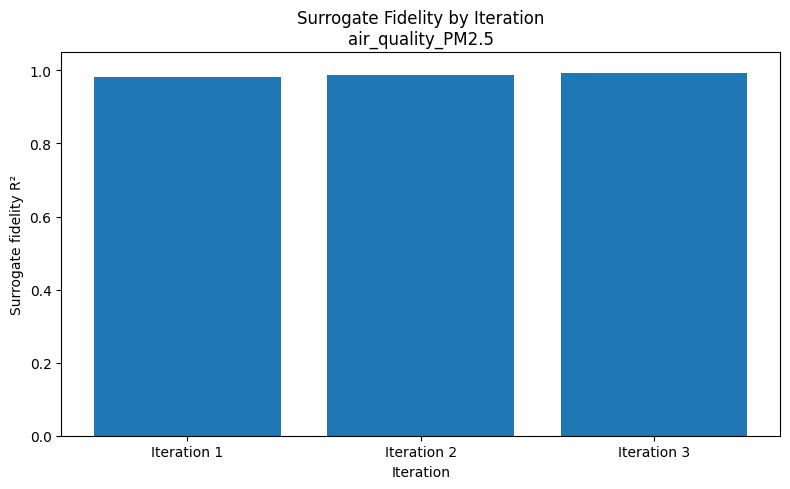

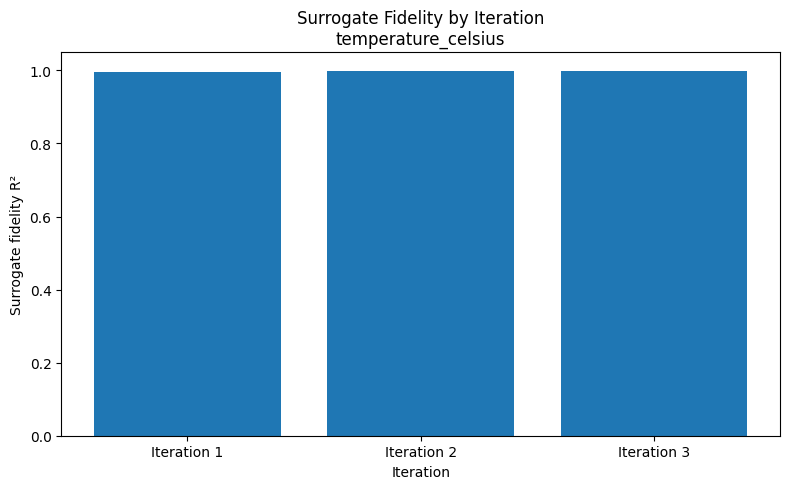

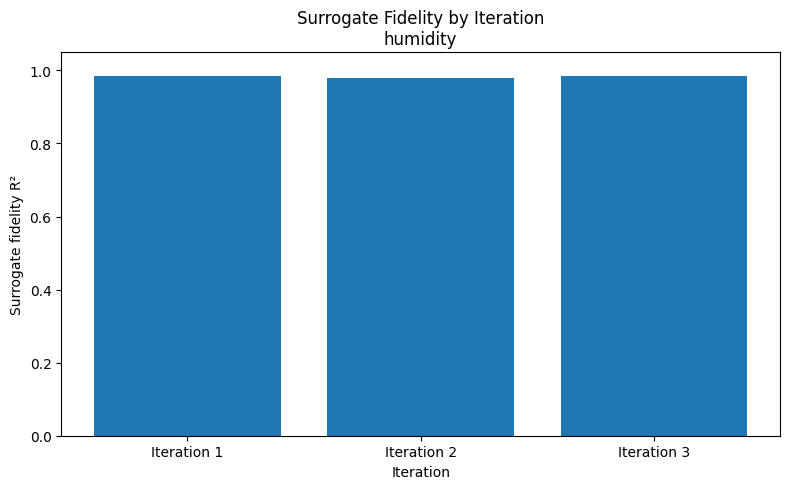

In [29]:
for target in targets:

    target_fidelity = fidelity_df[
        fidelity_df["Target"] == target
    ]

    plt.figure(figsize=(8, 5))

    plt.bar(
        target_fidelity["Iteration"],
        target_fidelity["R2"]
    )

    plt.ylim(0, 1.05)
    plt.xlabel("Iteration")
    plt.ylabel("Surrogate fidelity R²")

    plt.title(
        f"Surrogate Fidelity by Iteration\n{target}"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR /
        f"01_Fidelity_{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

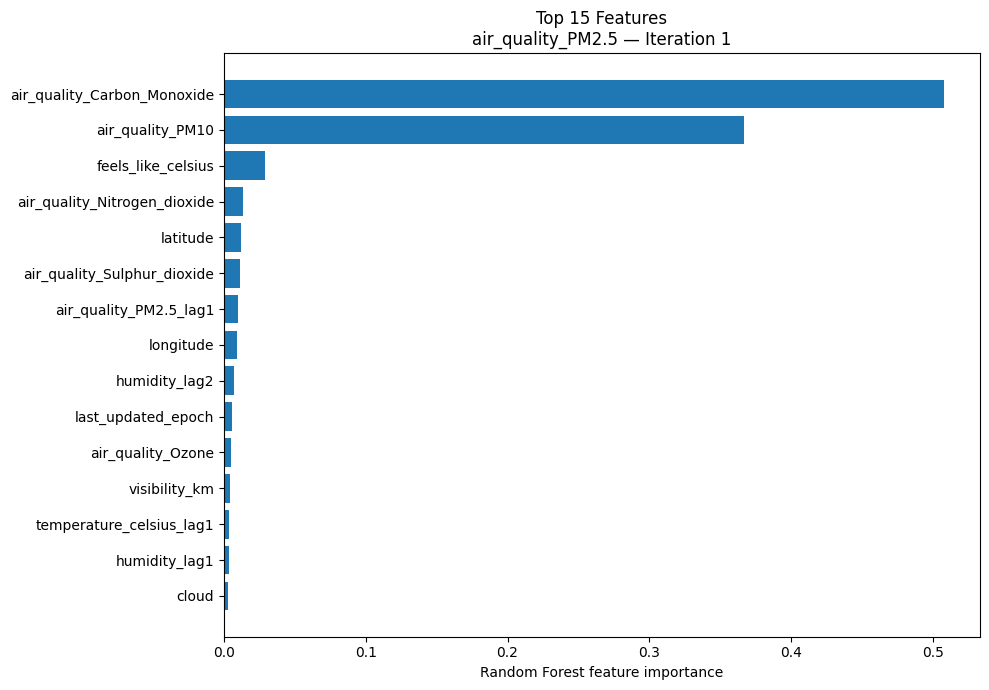

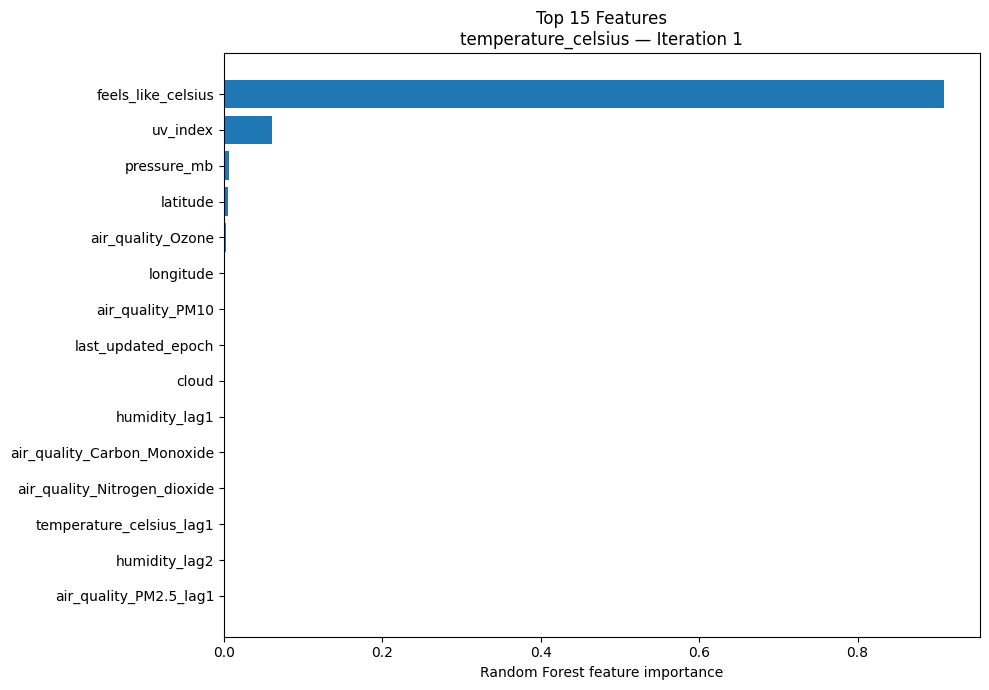

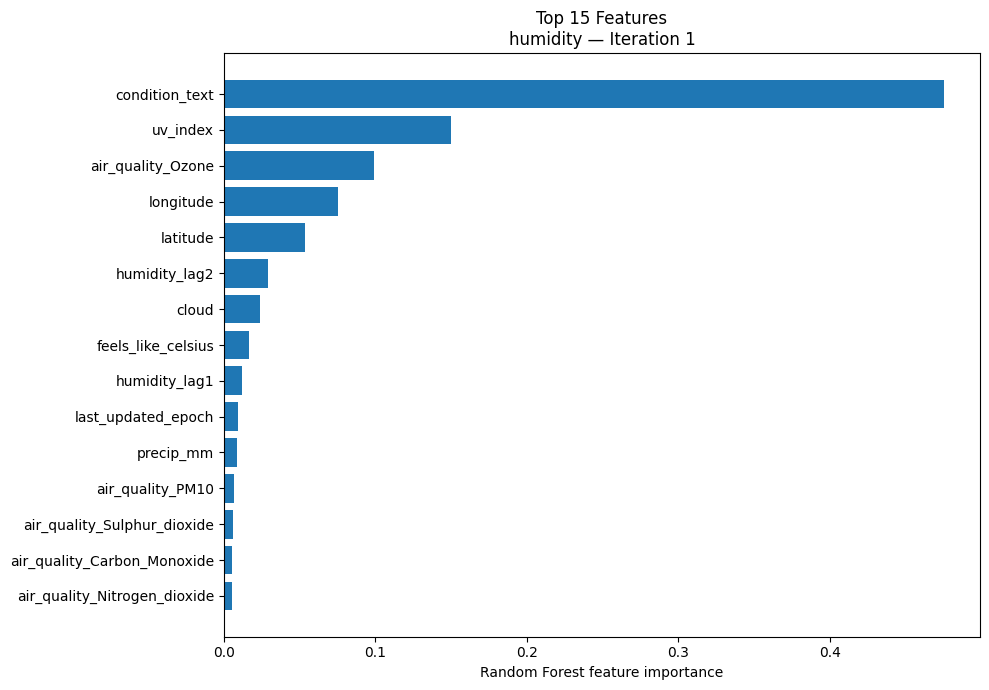

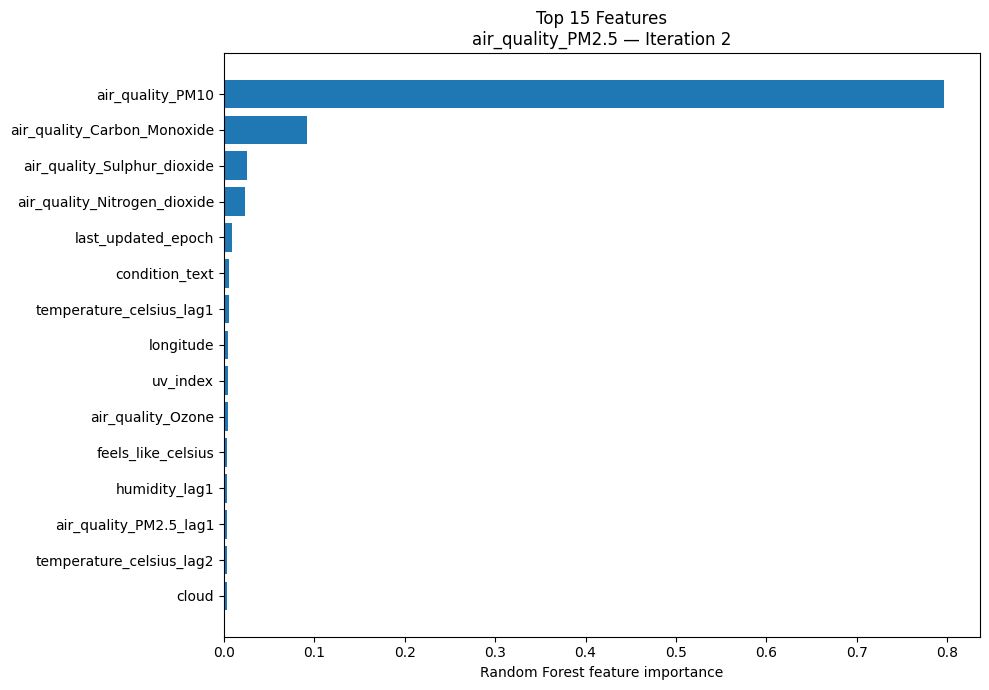

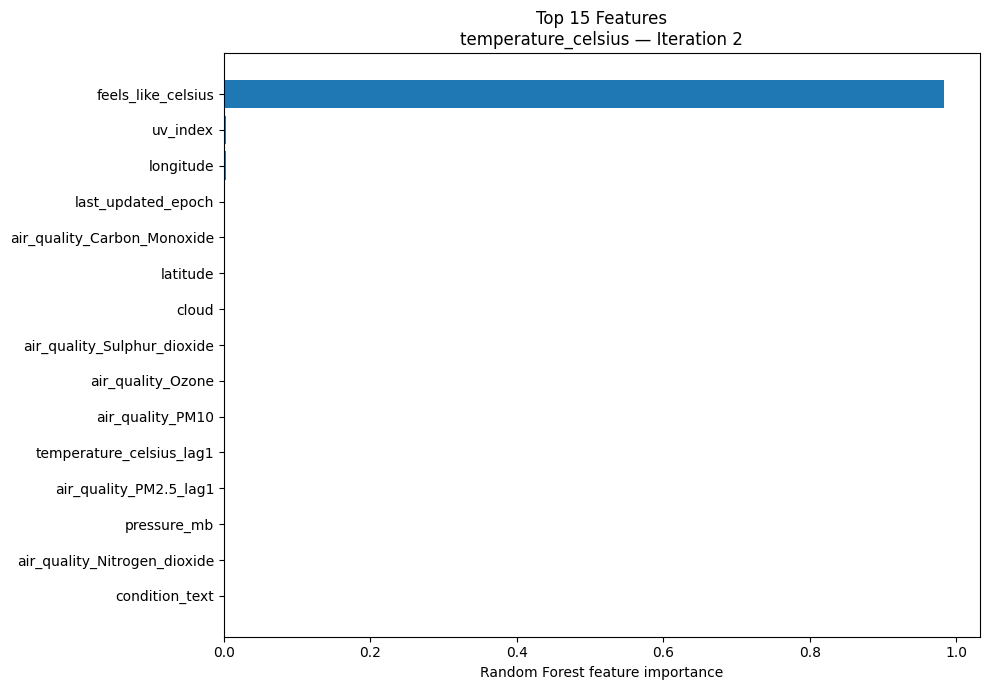

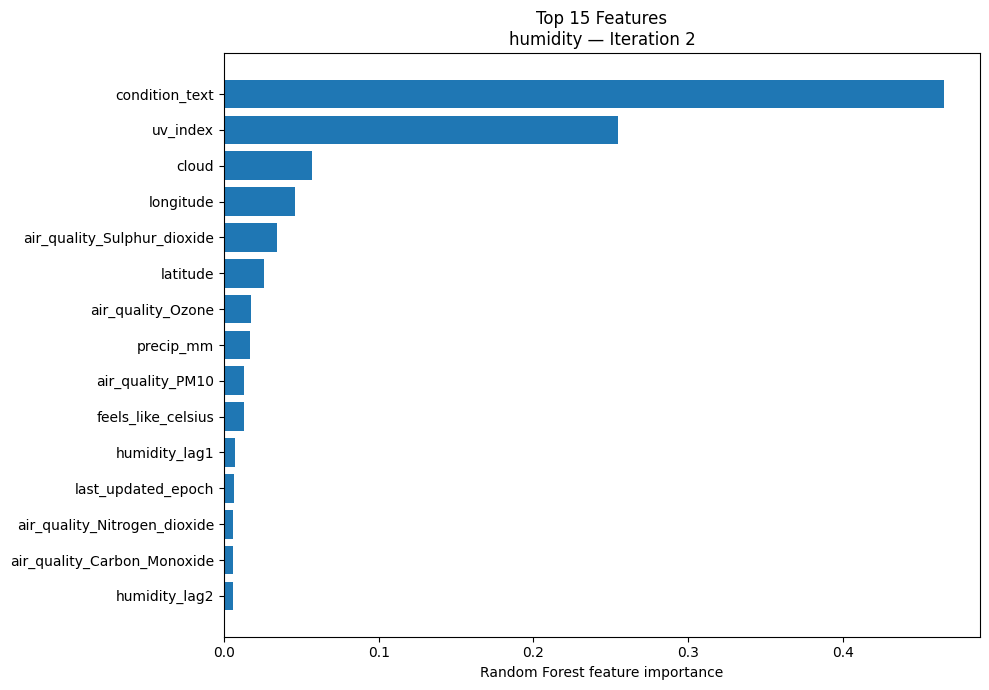

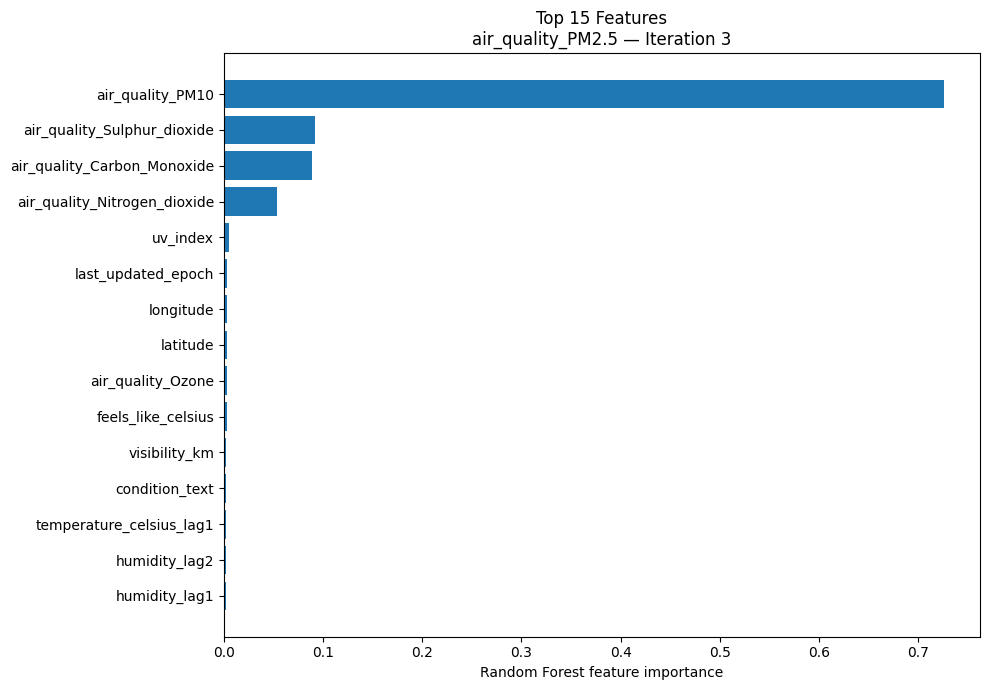

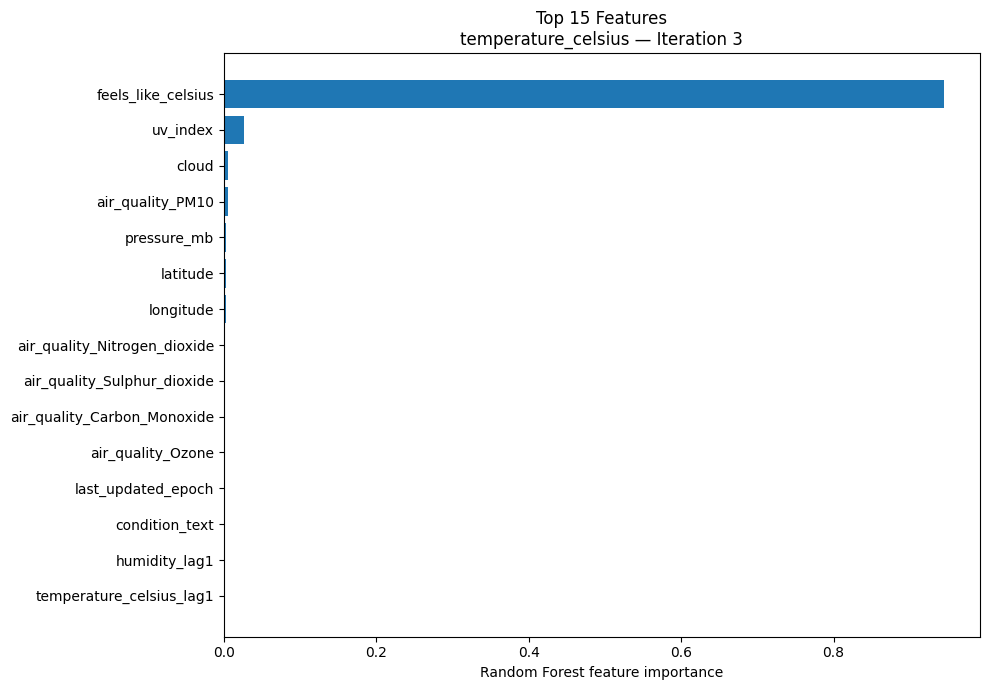

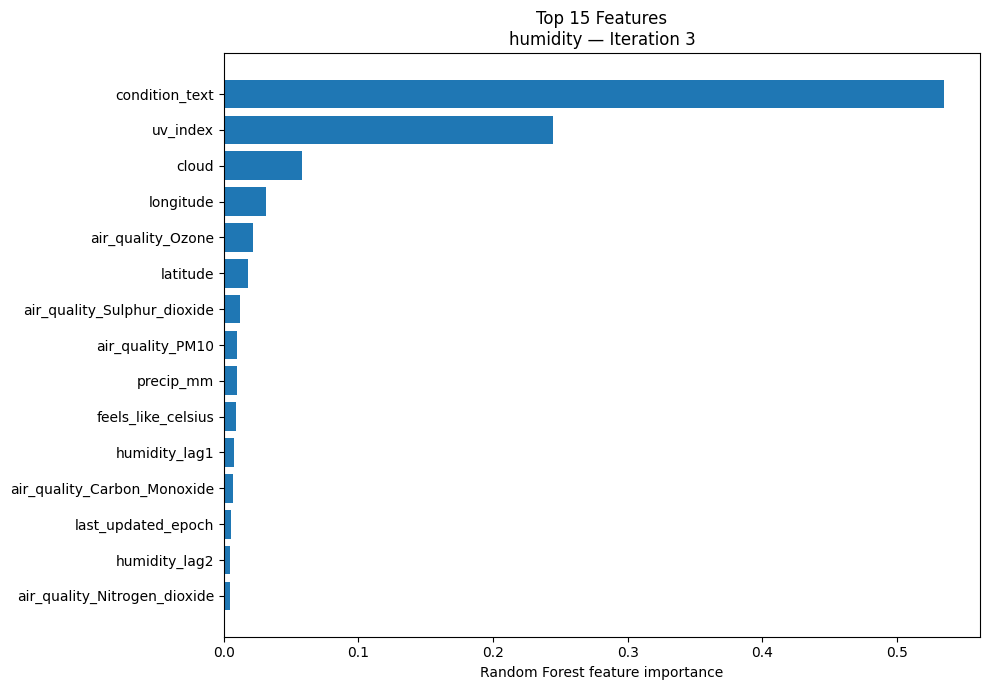

In [30]:
for iteration_name in iteration_data:

    for target in targets:

        plot_df = (
            feature_importance_df[
                (
                    feature_importance_df[
                        "Iteration"
                    ] == iteration_name
                )
                &
                (
                    feature_importance_df[
                        "Target"
                    ] == target
                )
            ]
            .sort_values(
                "Importance",
                ascending=False
            )
            .head(15)
        )

        plt.figure(figsize=(10, 7))

        plt.barh(
            plot_df["Feature"][::-1],
            plot_df["Importance"][::-1]
        )

        plt.xlabel(
            "Random Forest feature importance"
        )

        plt.title(
            f"Top 15 Features\n"
            f"{target} — {iteration_name}"
        )

        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR /
            (
                "02_Feature_Importance_"
                f"{safe_name(target)}_"
                f"{safe_name(iteration_name)}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

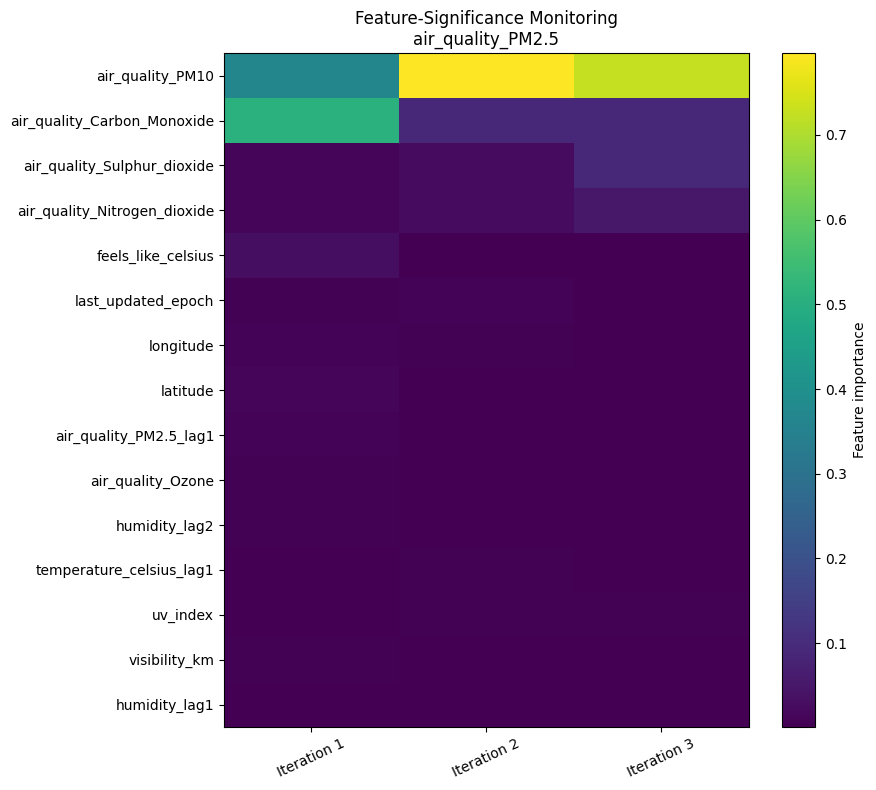

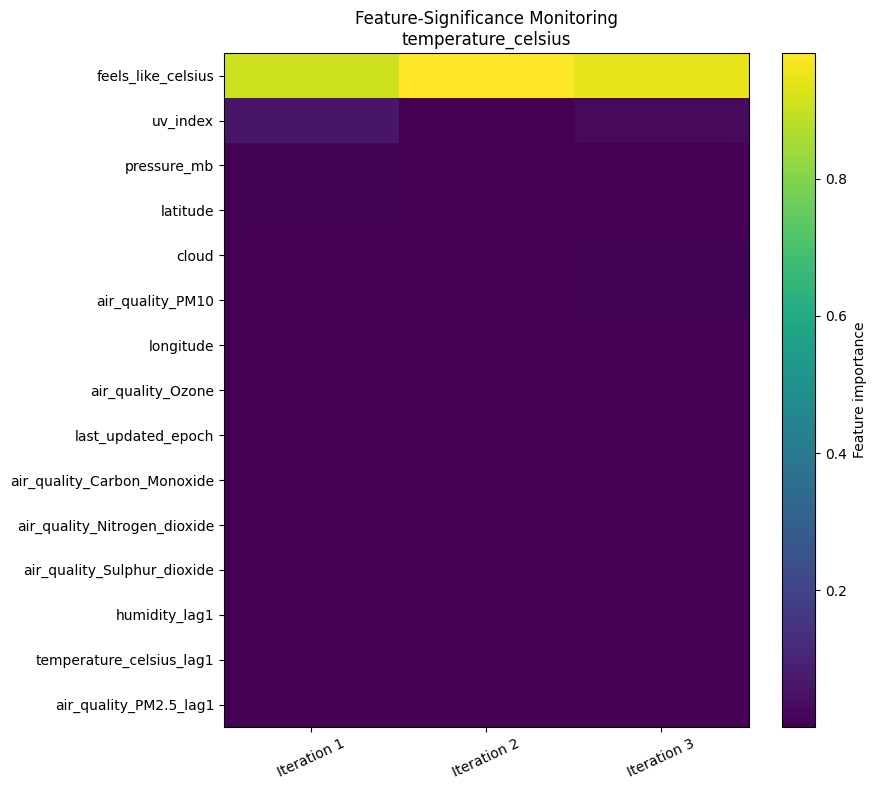

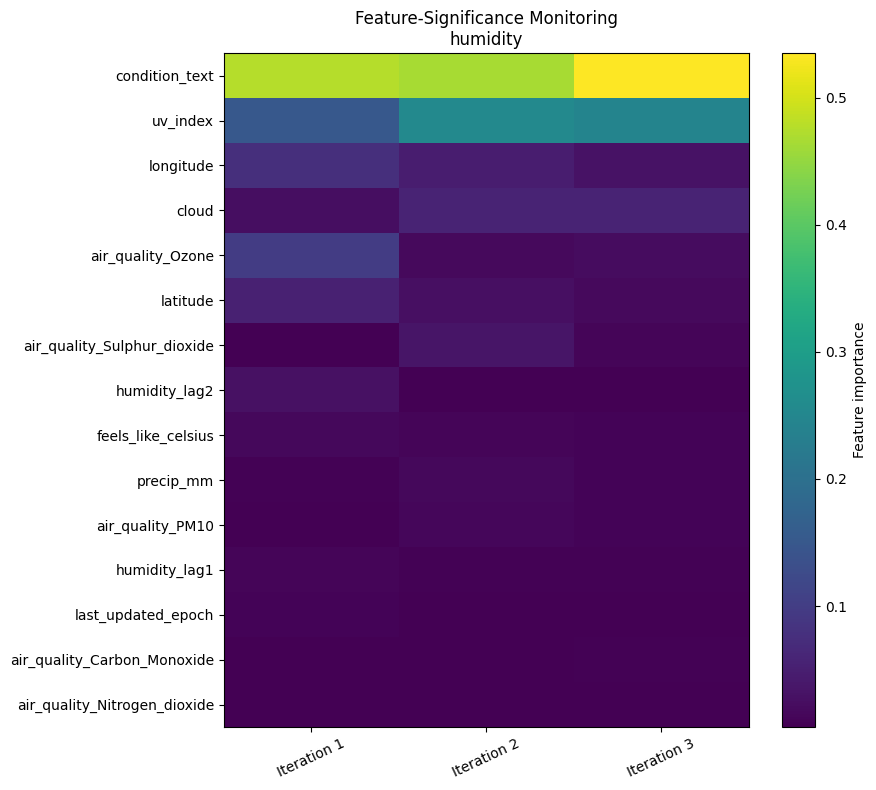

In [31]:
for target in targets:

    target_importance = feature_importance_df[
        feature_importance_df["Target"] == target
    ]

    importance_matrix = (
        target_importance.pivot_table(
            index="Feature",
            columns="Iteration",
            values="Importance",
            aggfunc="mean"
        )
        .fillna(0)
        .reindex(
            columns=[
                "Iteration 1",
                "Iteration 2",
                "Iteration 3"
            ]
        )
    )

    top_features = (
        importance_matrix
        .mean(axis=1)
        .sort_values(ascending=False)
        .head(15)
        .index
    )

    plot_matrix = importance_matrix.loc[
        top_features
    ]

    plt.figure(figsize=(9, 8))

    image = plt.imshow(
        plot_matrix.values,
        aspect="auto"
    )

    plt.colorbar(
        image,
        label="Feature importance"
    )

    plt.xticks(
        range(len(plot_matrix.columns)),
        plot_matrix.columns,
        rotation=25
    )

    plt.yticks(
        range(len(plot_matrix.index)),
        plot_matrix.index
    )

    plt.title(
        f"Feature-Significance Monitoring\n{target}"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR /
        f"03_Feature_Monitoring_{safe_name(target)}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

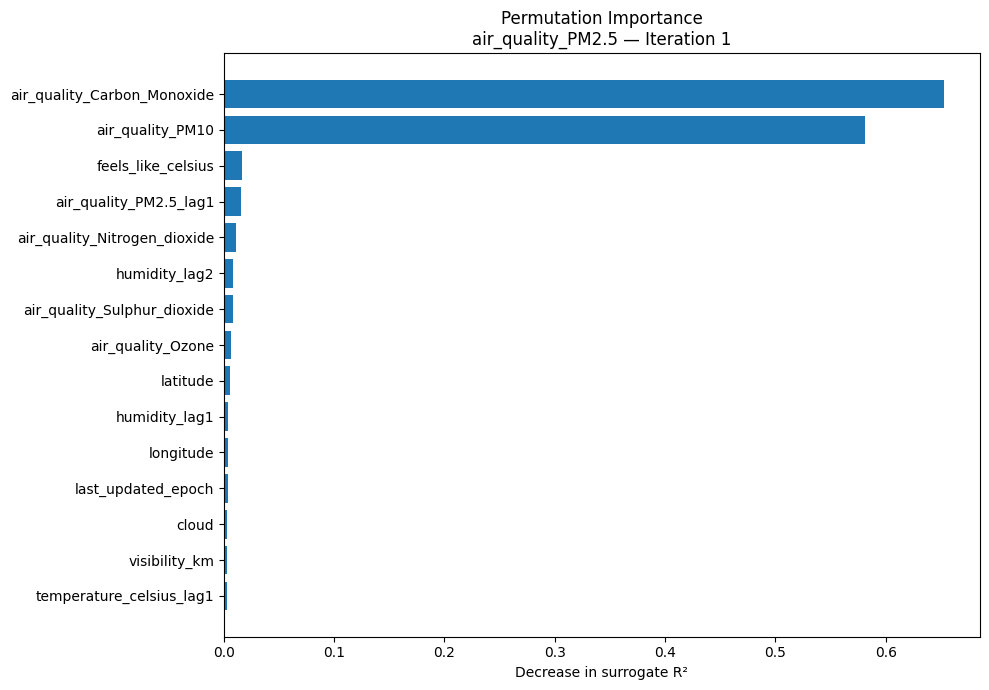

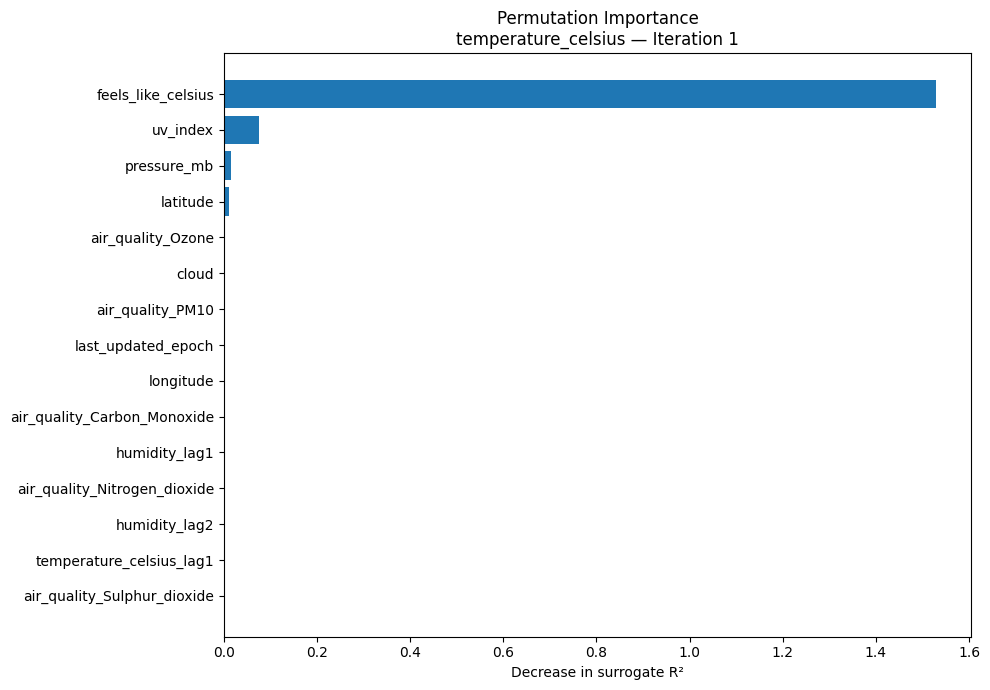

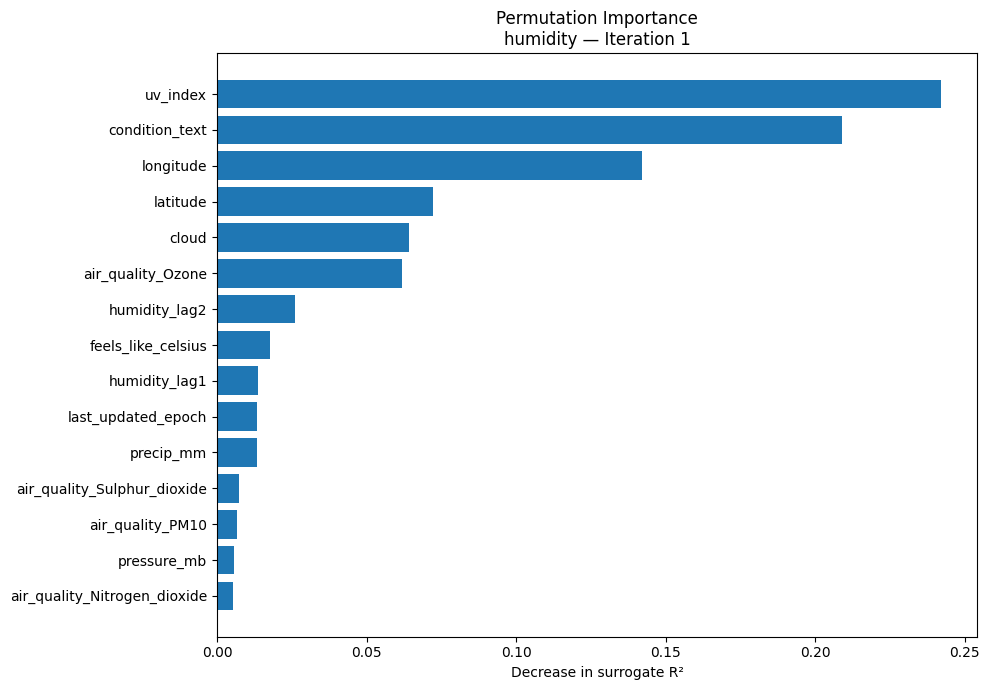

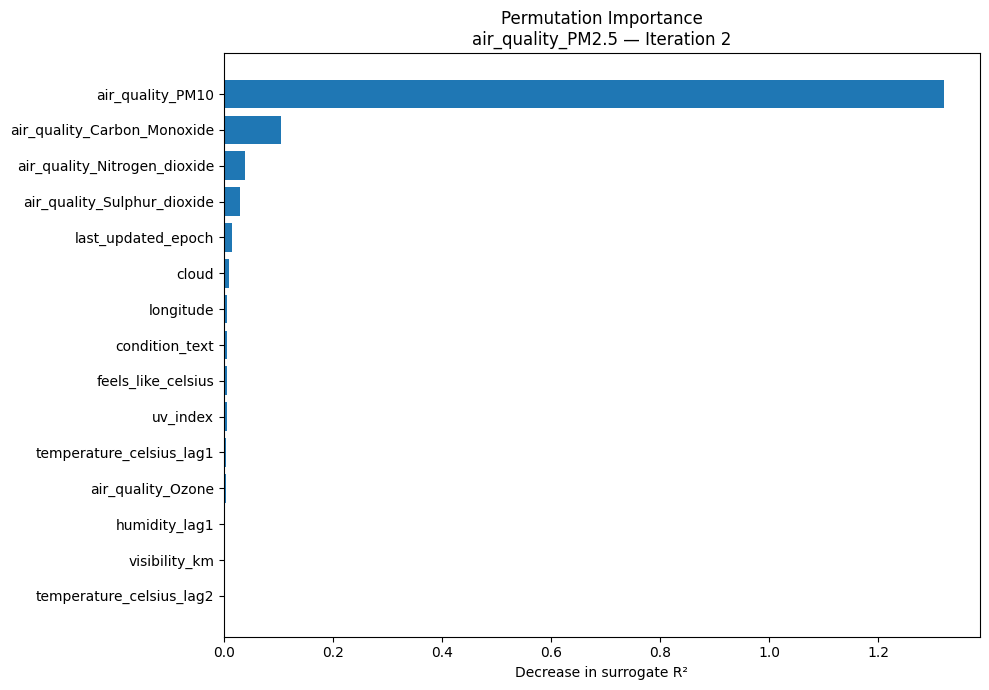

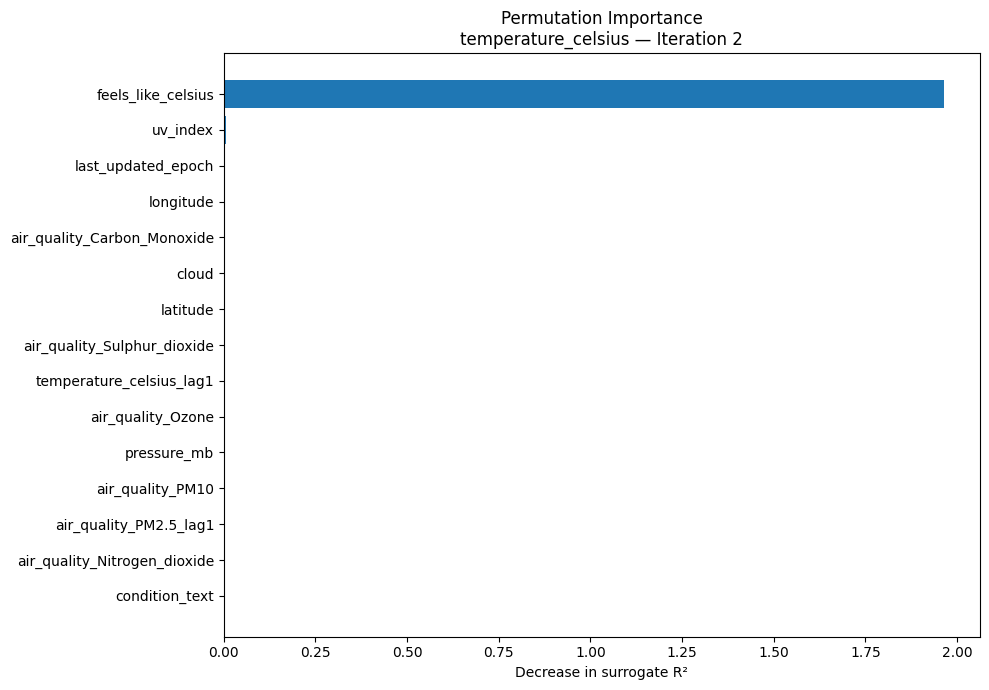

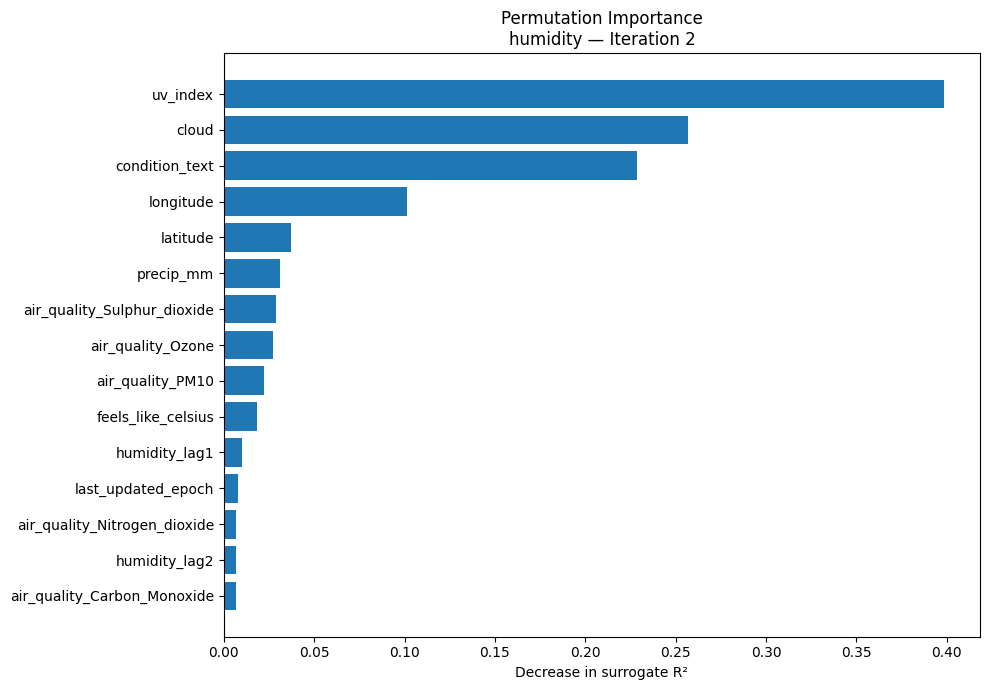

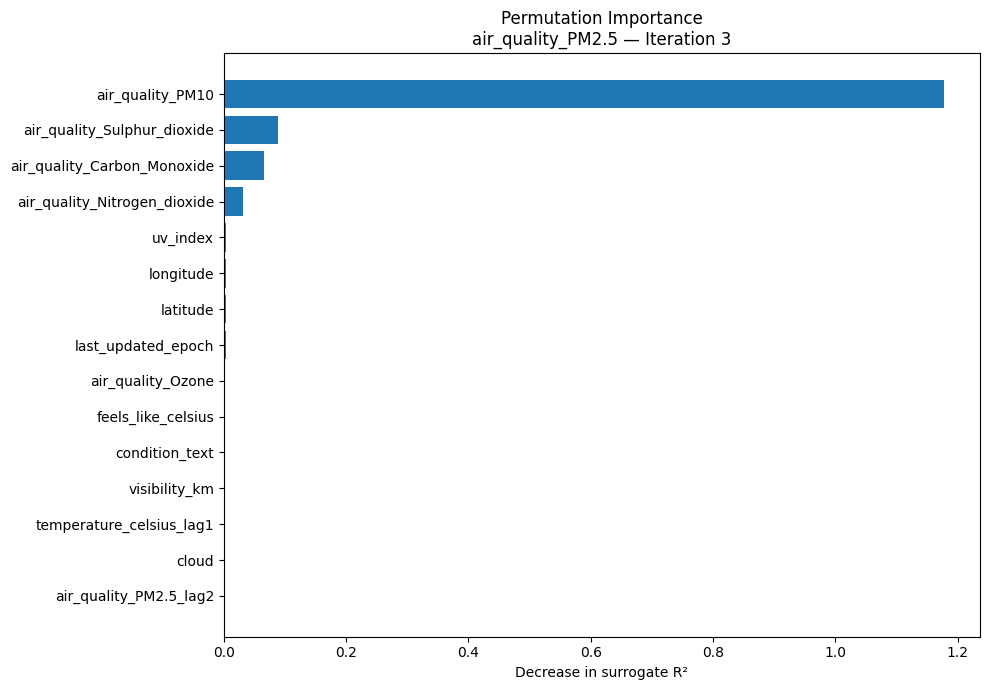

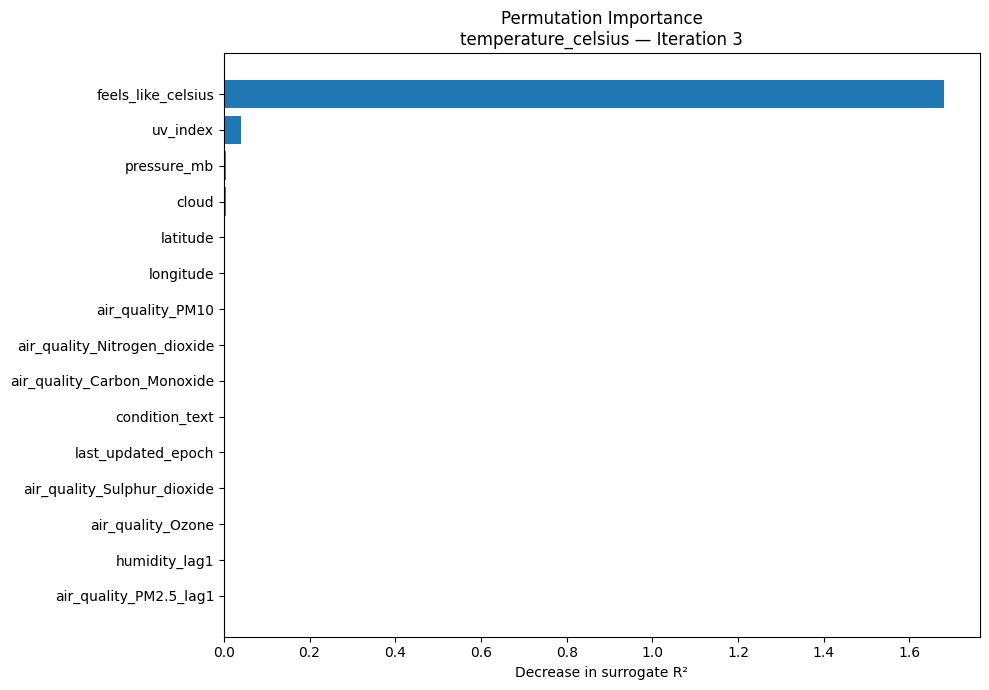

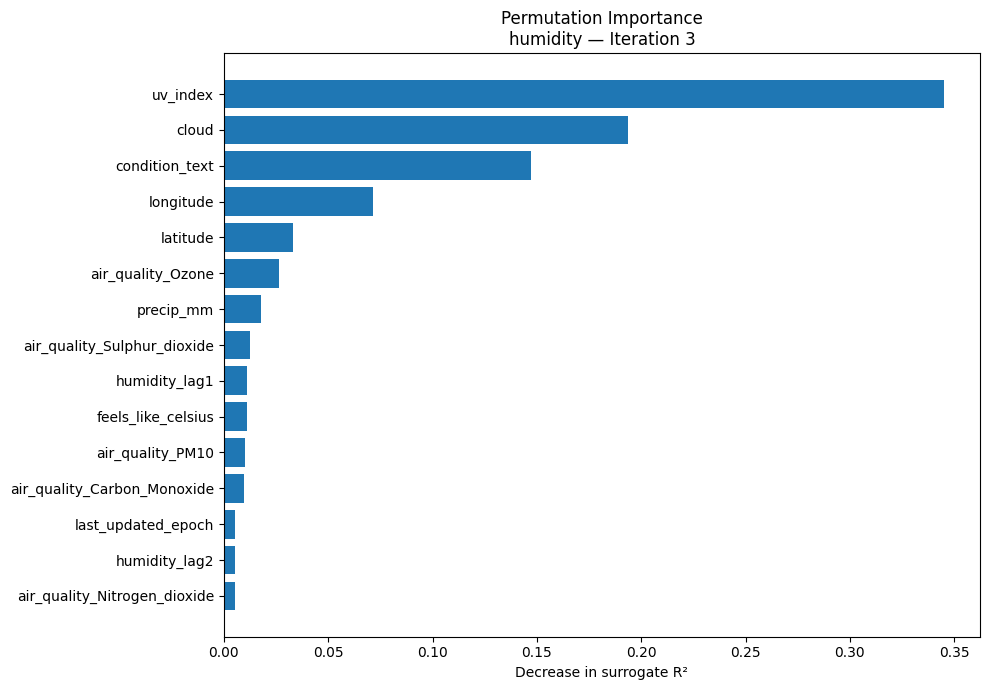

In [34]:
permutation_rows = []

for iteration_name in iteration_data:

    for target in targets:

        model_info = surrogate_models[
            iteration_name
        ][target]

        X_full = model_info["X"]
        y_full = model_info["y_hybrid"]

        sample_size = min(
            PERMUTATION_SAMPLE_SIZE,
            len(X_full)
        )

        random_generator = np.random.RandomState(
            RANDOM_STATE
        )

        selected_positions = (
            random_generator.choice(
                len(X_full),
                size=sample_size,
                replace=False
            )
        )

        X_permutation = (
            X_full
            .iloc[selected_positions]
            .reset_index(drop=True)
        )

        y_permutation = y_full[
            selected_positions
        ]

        permutation_result = permutation_importance(
            estimator=model_info["model"],
            X=X_permutation,
            y=y_permutation,
            n_repeats=5,
            scoring="r2",
            n_jobs=-1,
            random_state=RANDOM_STATE
        )

        plot_df = pd.DataFrame({
            "Feature": X_permutation.columns,
            "Importance": (
                permutation_result
                .importances_mean
            )
        }).sort_values(
            "Importance",
            ascending=False
        ).head(15)

        for _, row in plot_df.iterrows():

            permutation_rows.append({
                "Iteration": iteration_name,
                "Target": target,
                "Feature": row["Feature"],
                "Importance": row["Importance"]
            })

        plt.figure(figsize=(10, 7))

        plt.barh(
            plot_df["Feature"][::-1],
            plot_df["Importance"][::-1]
        )

        plt.xlabel("Decrease in surrogate R²")

        plt.title(
            f"Permutation Importance\n"
            f"{target} — {iteration_name}"
        )

        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR /
            (
                "04_Permutation_Importance_"
                f"{safe_name(target)}_"
                f"{safe_name(iteration_name)}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

permutation_df = pd.DataFrame(
    permutation_rows
)

permutation_df.to_csv(
    OUTPUT_DIR / "permutation_importance.csv",
    index=False
)

In [35]:
def standardise_shap_values(shap_output):
    """Convert different SHAP outputs into a 2D array."""

    if isinstance(shap_output, list):
        shap_output = shap_output[0]

    if hasattr(shap_output, "values"):
        shap_output = shap_output.values

    shap_array = np.asarray(
        shap_output
    )

    if (
        shap_array.ndim == 3
        and shap_array.shape[-1] == 1
    ):
        shap_array = shap_array[:, :, 0]

    if shap_array.ndim != 2:
        raise ValueError(
            "Unexpected SHAP output shape: "
            f"{shap_array.shape}"
        )

    return shap_array

In [36]:
shap_results = {}

for iteration_name in iteration_data:

    shap_results[iteration_name] = {}

    for target in targets:

        print(
            "Calculating SHAP:",
            iteration_name,
            target
        )

        model_info = surrogate_models[
            iteration_name
        ][target]

        X_full = model_info["X"]

        sample_size = min(
            SHAP_SAMPLE_SIZE,
            len(X_full)
        )

        X_shap = (
            X_full.sample(
                n=sample_size,
                random_state=RANDOM_STATE
            )
            .reset_index(drop=True)
        )

        explainer = shap.TreeExplainer(
            model_info["model"]
        )

        raw_shap_values = (
            explainer.shap_values(
                X_shap,
                check_additivity=False
            )
        )

        shap_values = standardise_shap_values(
            raw_shap_values
        )

        shap_results[
            iteration_name
        ][target] = {
            "explainer": explainer,
            "X_shap": X_shap,
            "shap_values": shap_values
        }

        print(
            "SHAP shape:",
            shap_values.shape
        )

print("All SHAP values calculated.")

Calculating SHAP: Iteration 1 air_quality_PM2.5
SHAP shape: (500, 21)
Calculating SHAP: Iteration 1 temperature_celsius
SHAP shape: (500, 21)
Calculating SHAP: Iteration 1 humidity
SHAP shape: (500, 21)
Calculating SHAP: Iteration 2 air_quality_PM2.5
SHAP shape: (500, 21)
Calculating SHAP: Iteration 2 temperature_celsius
SHAP shape: (500, 21)
Calculating SHAP: Iteration 2 humidity
SHAP shape: (500, 21)
Calculating SHAP: Iteration 3 air_quality_PM2.5
SHAP shape: (500, 21)
Calculating SHAP: Iteration 3 temperature_celsius
SHAP shape: (500, 21)
Calculating SHAP: Iteration 3 humidity
SHAP shape: (500, 21)
All SHAP values calculated.


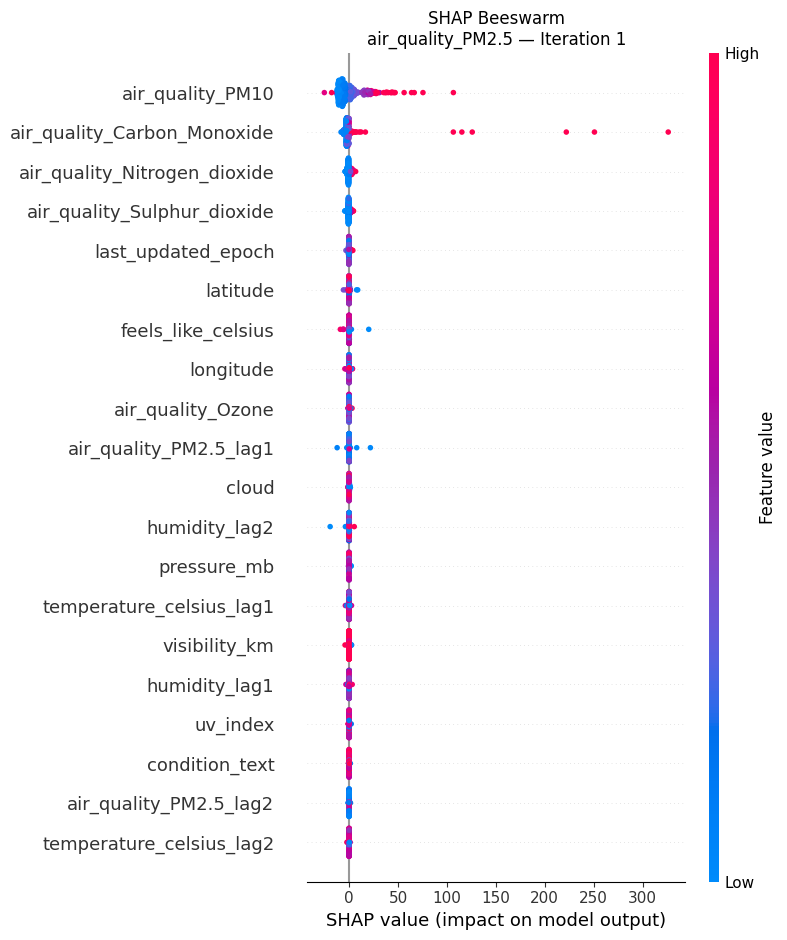

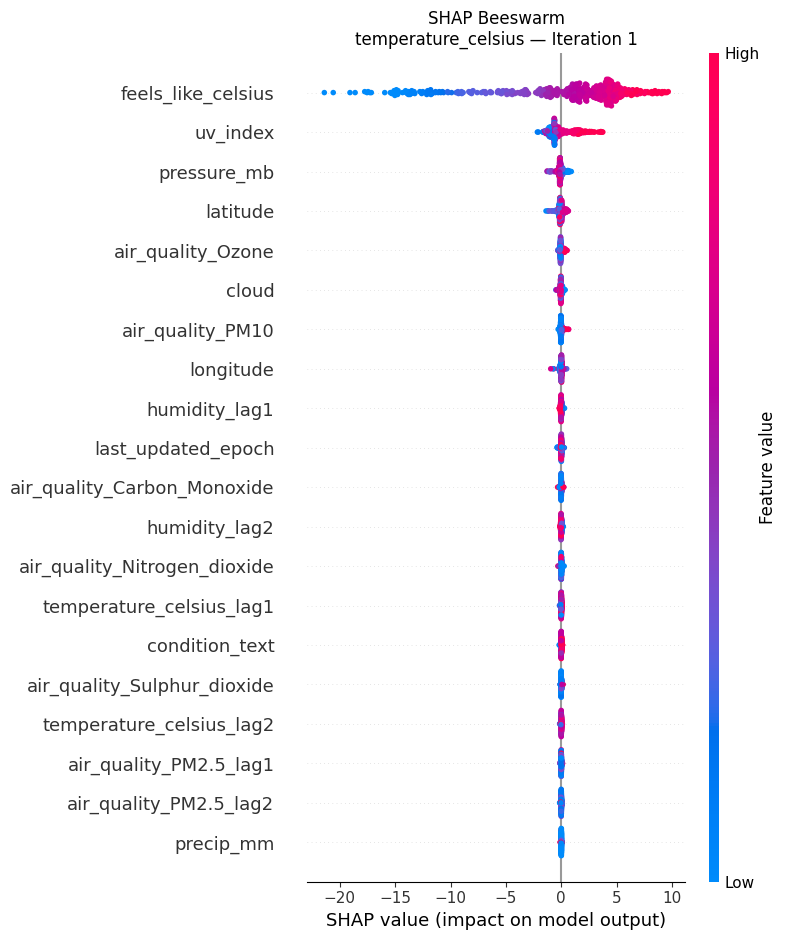

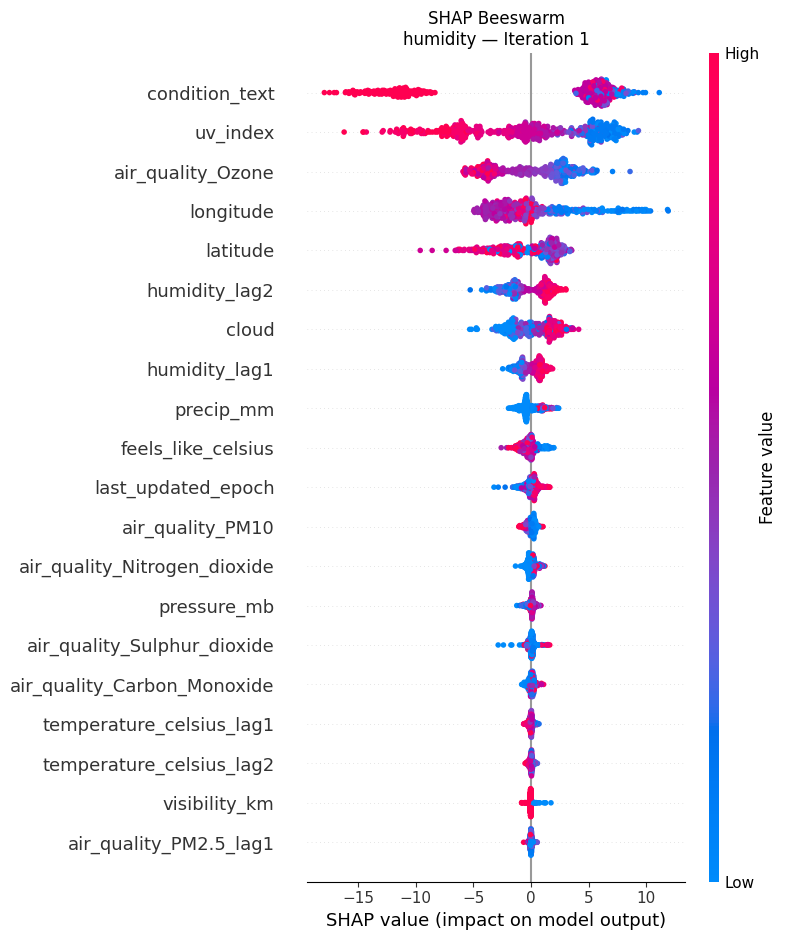

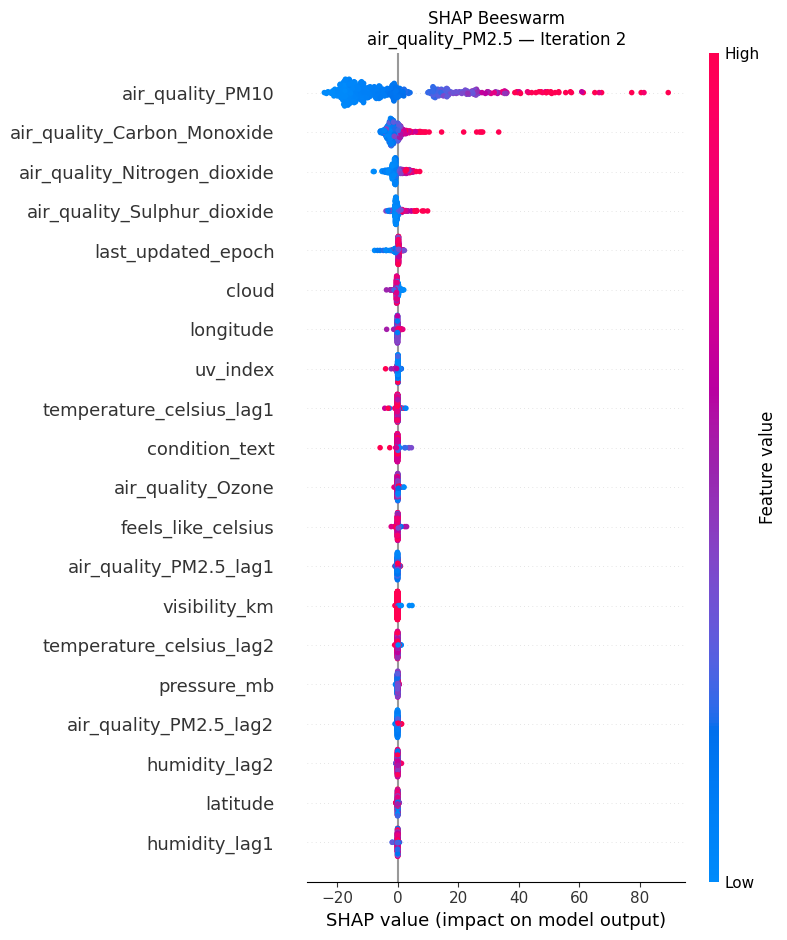

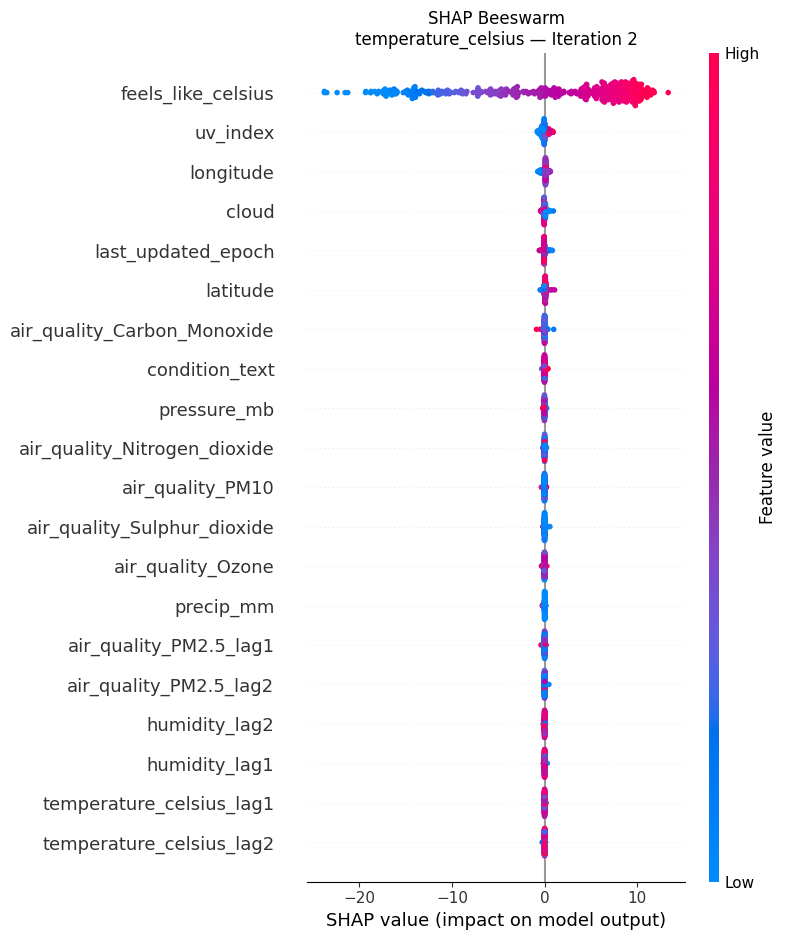

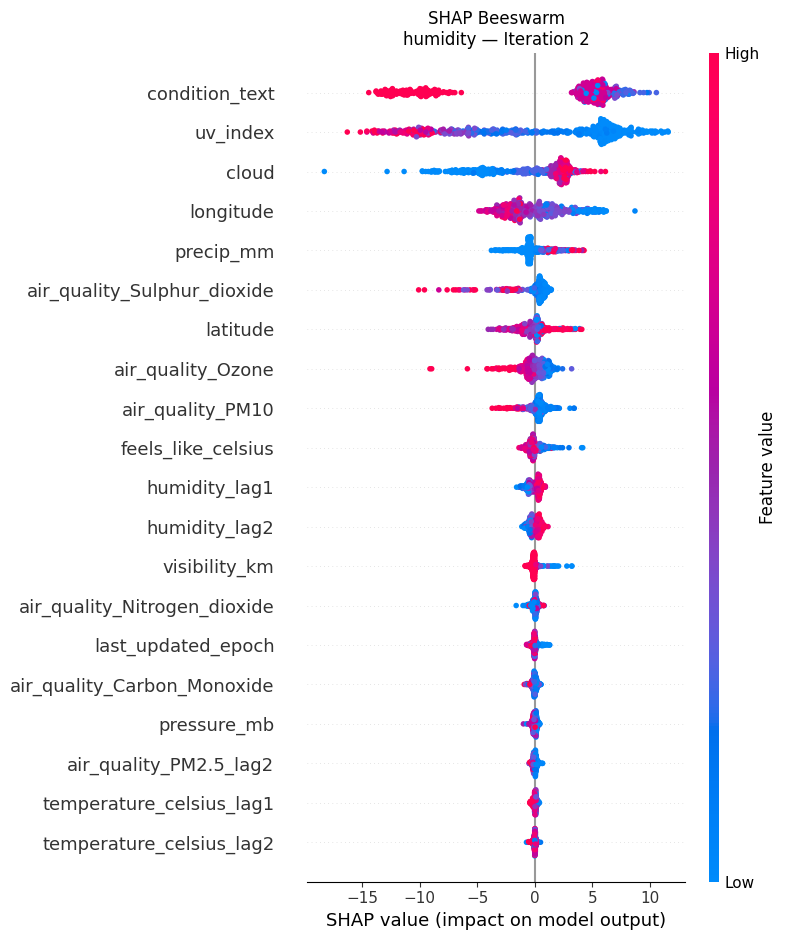

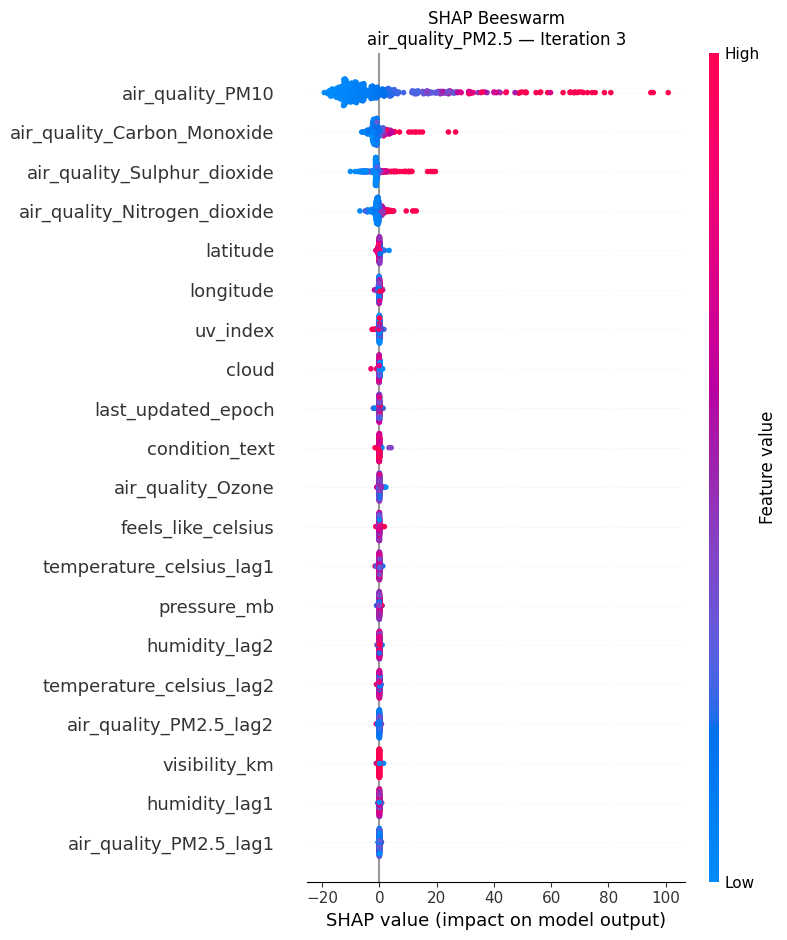

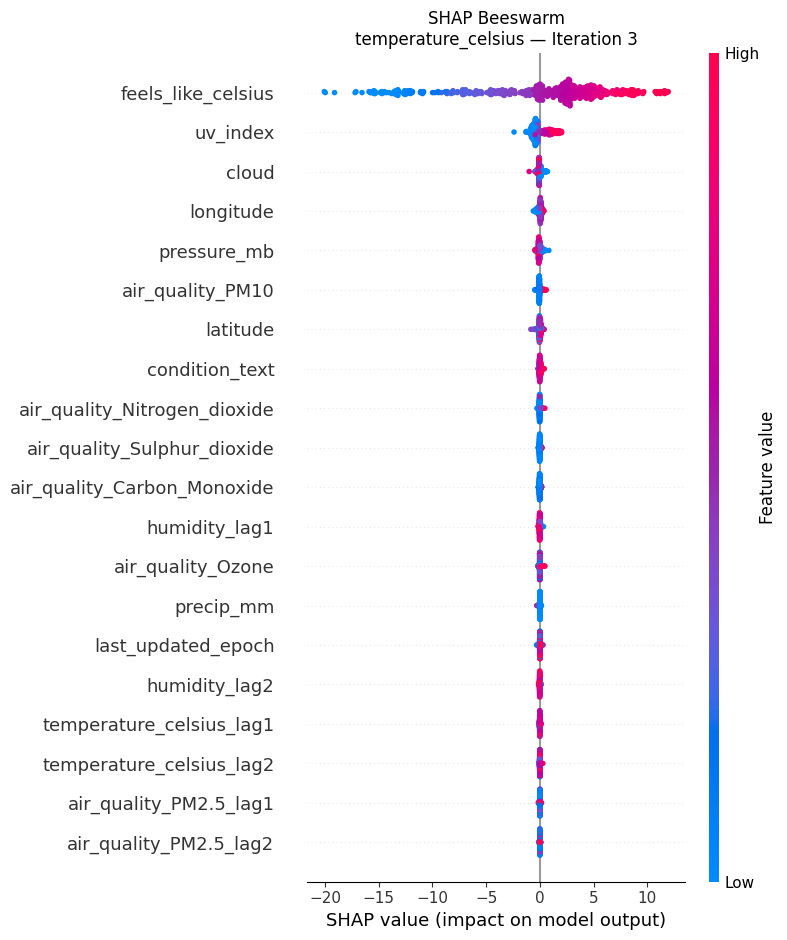

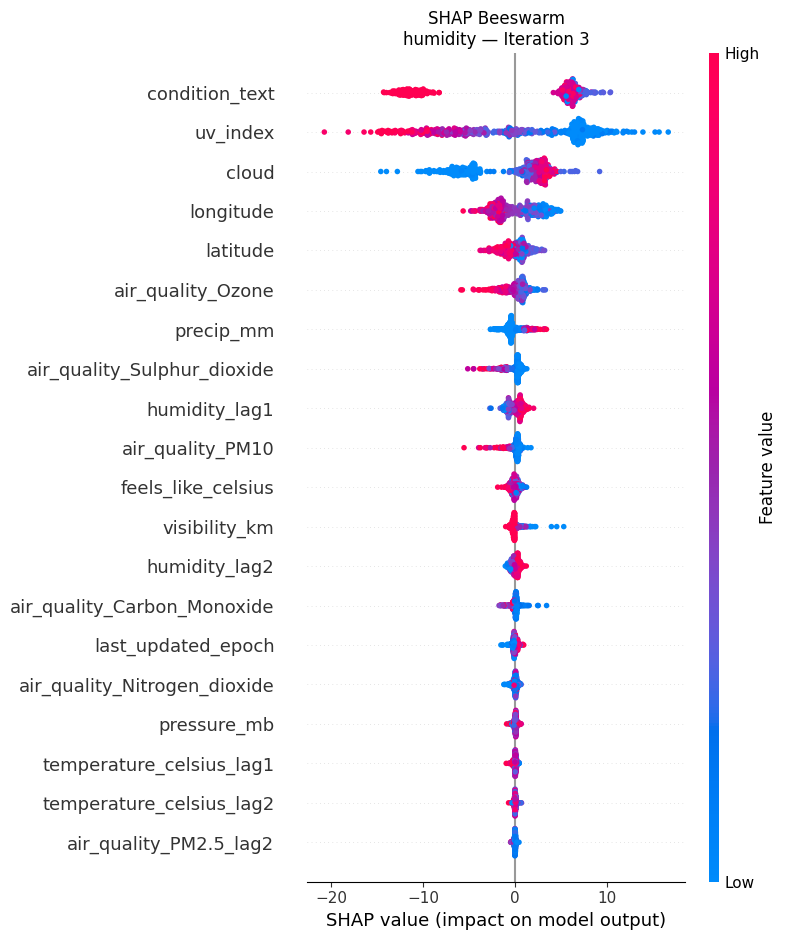

In [37]:
for iteration_name in iteration_data:

    for target in targets:

        result = shap_results[
            iteration_name
        ][target]

        X_shap = result["X_shap"]
        shap_values = result["shap_values"]

        shap.summary_plot(
            shap_values,
            X_shap,
            feature_names=X_shap.columns,
            show=False
        )

        plt.title(
            f"SHAP Beeswarm\n"
            f"{target} — {iteration_name}"
        )

        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR /
            (
                "05_SHAP_Beeswarm_"
                f"{safe_name(target)}_"
                f"{safe_name(iteration_name)}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

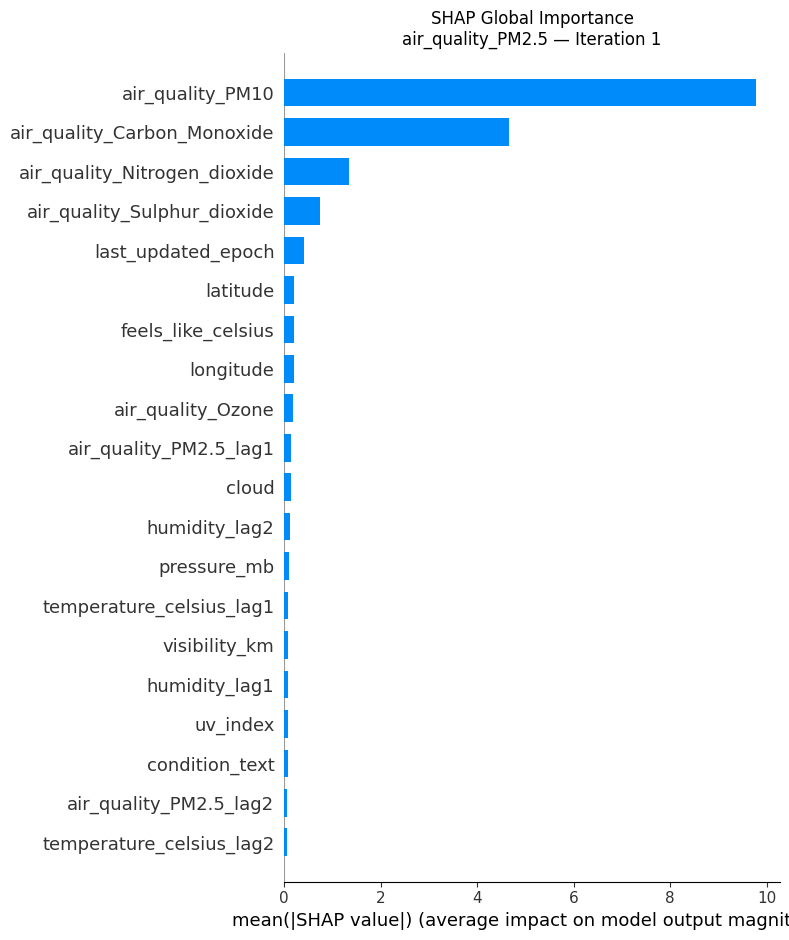

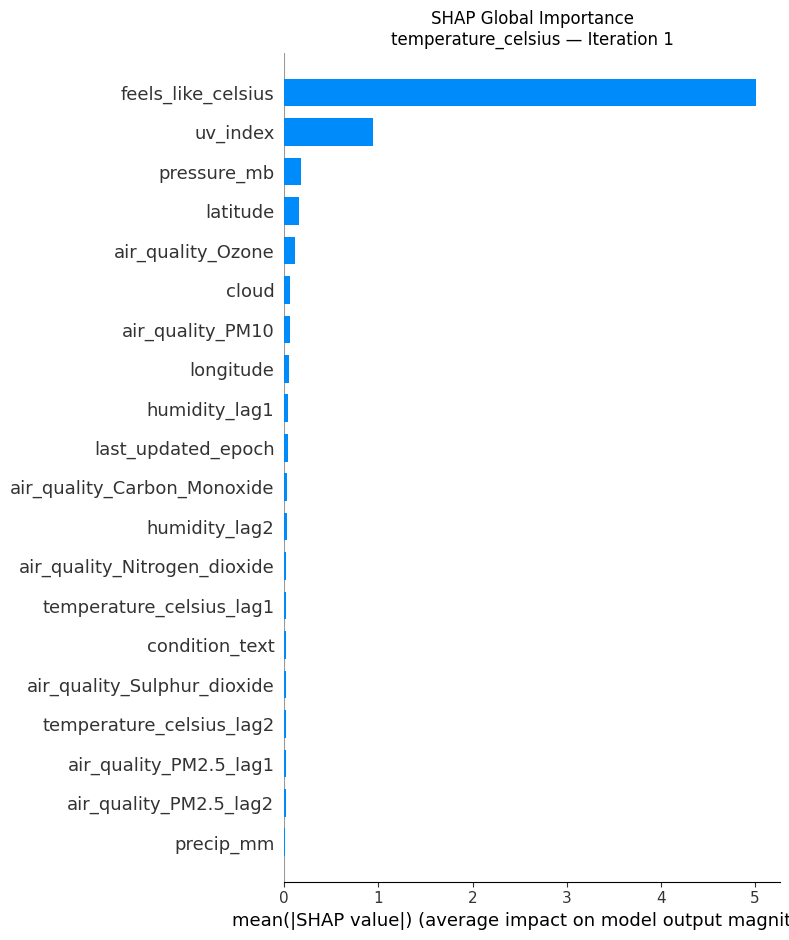

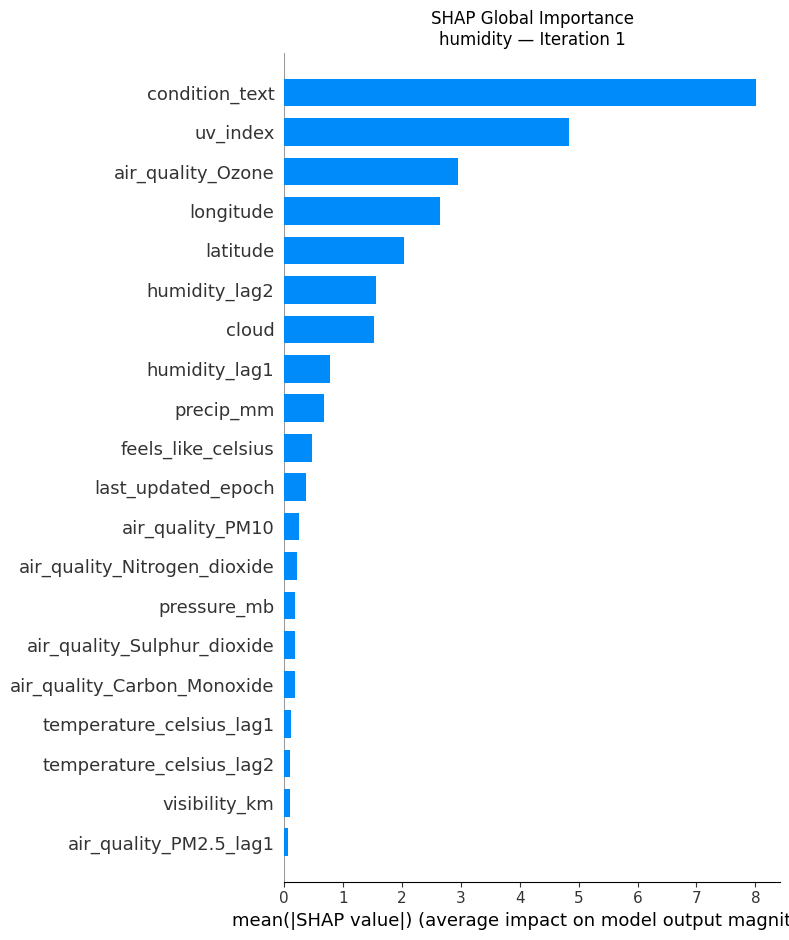

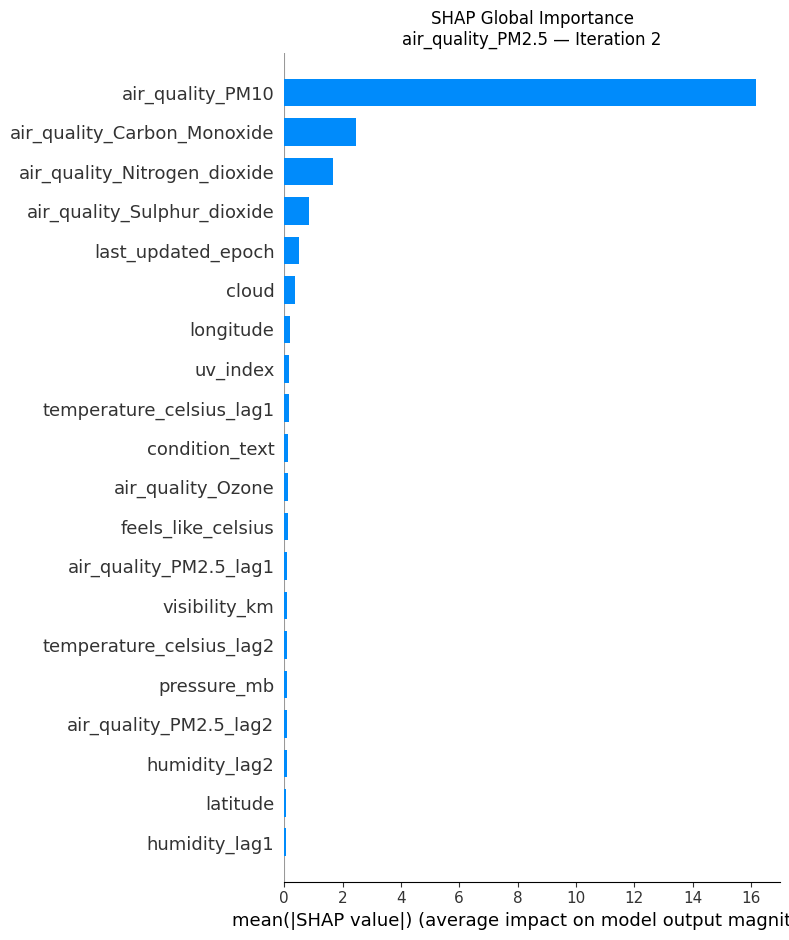

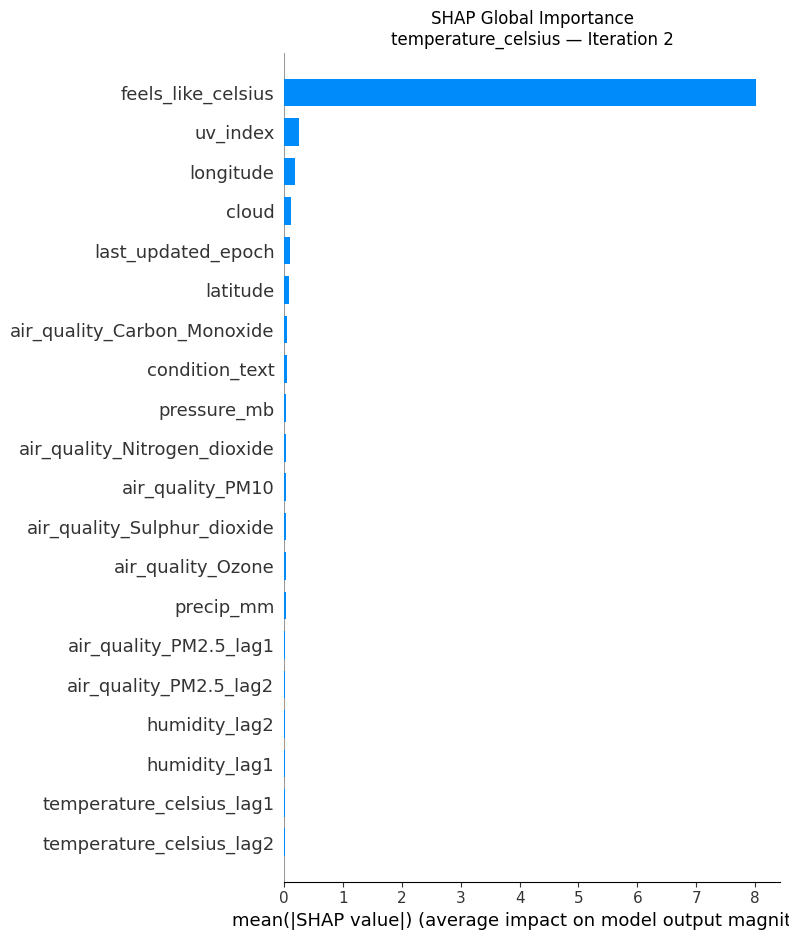

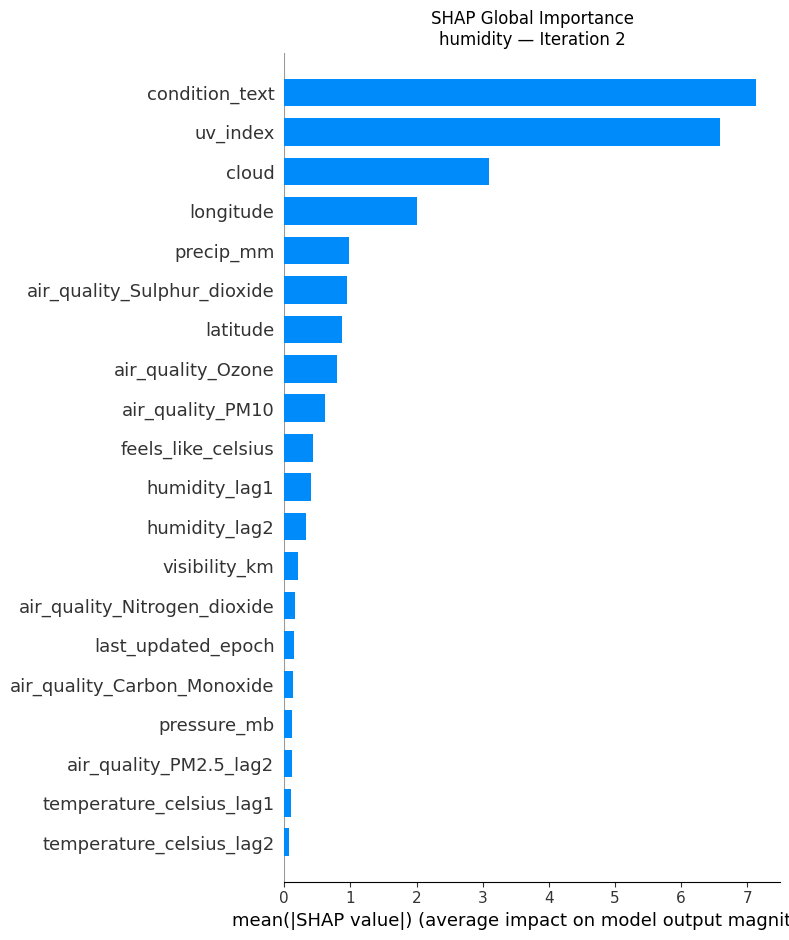

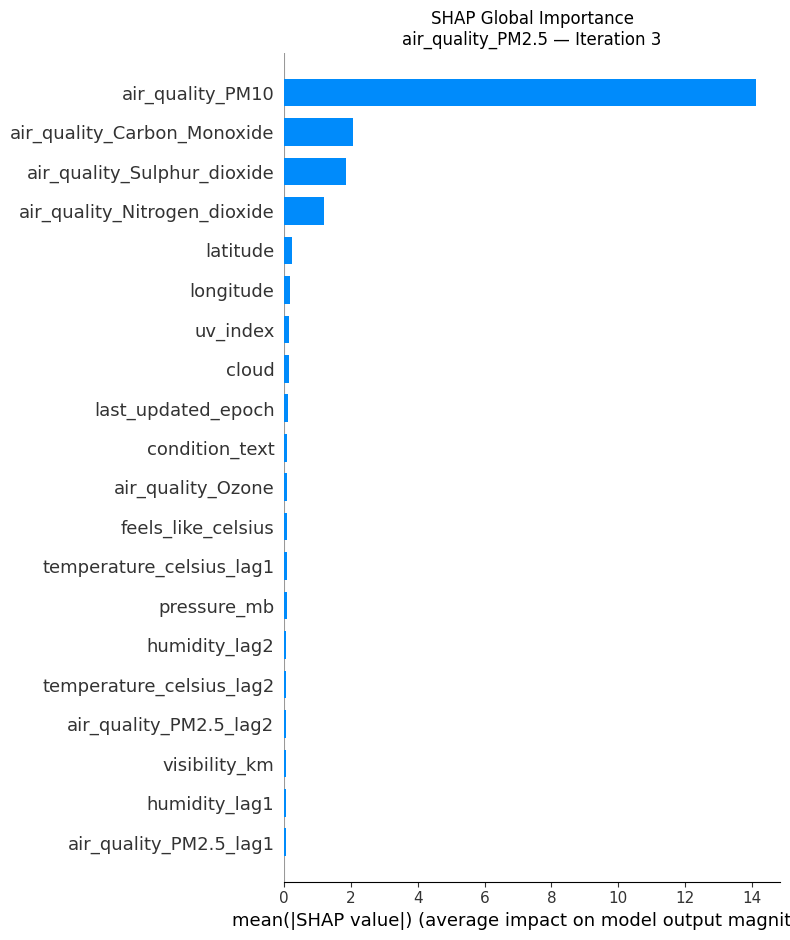

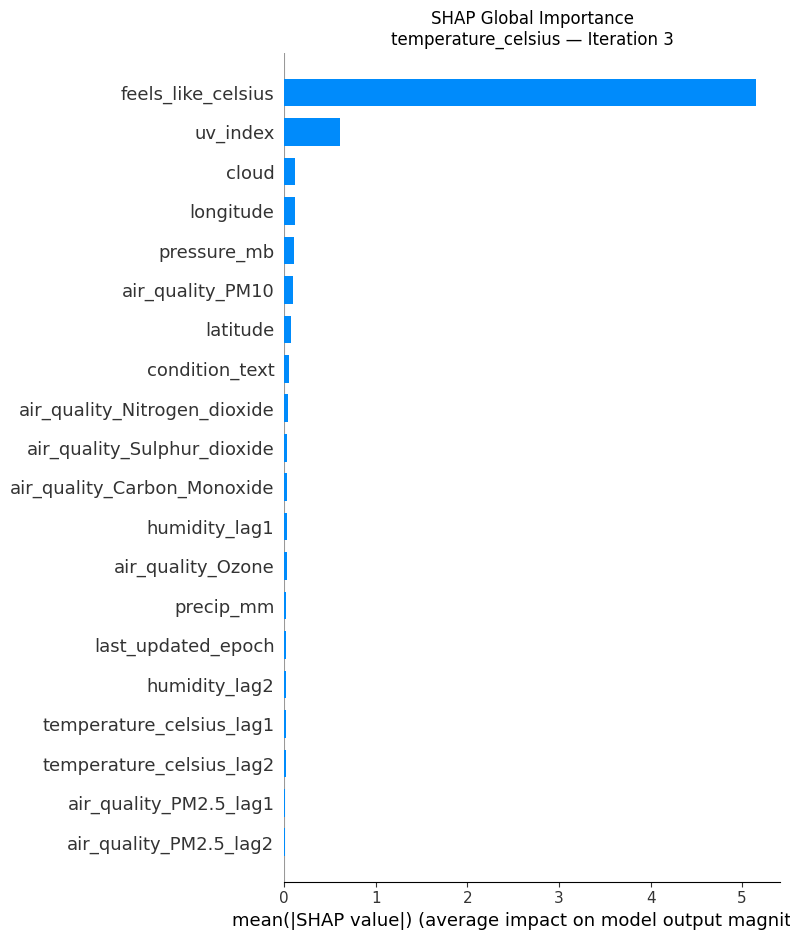

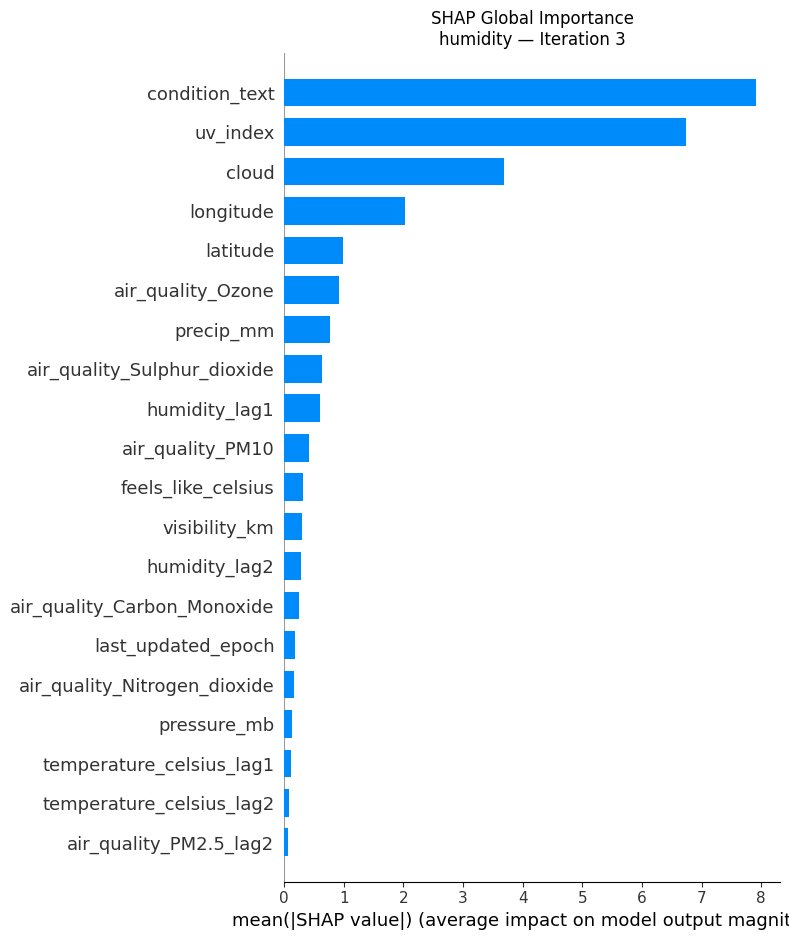

In [38]:
for iteration_name in iteration_data:

    for target in targets:

        result = shap_results[
            iteration_name
        ][target]

        X_shap = result["X_shap"]
        shap_values = result["shap_values"]

        shap.summary_plot(
            shap_values,
            X_shap,
            feature_names=X_shap.columns,
            plot_type="bar",
            show=False
        )

        plt.title(
            f"SHAP Global Importance\n"
            f"{target} — {iteration_name}"
        )

        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR /
            (
                "06_SHAP_Bar_"
                f"{safe_name(target)}_"
                f"{safe_name(iteration_name)}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

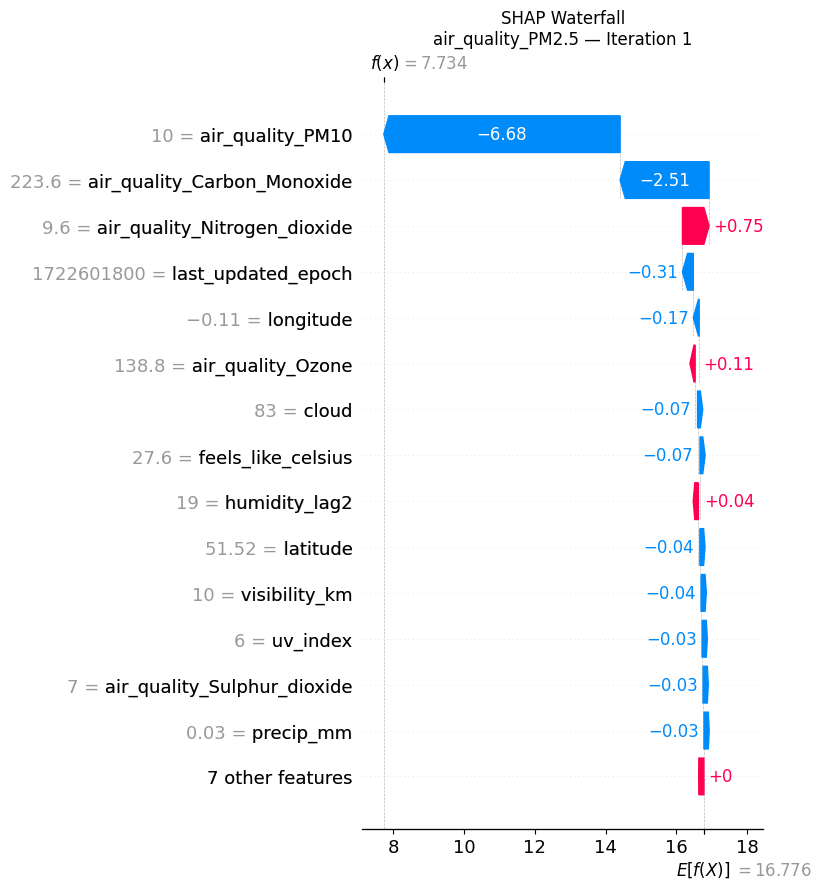

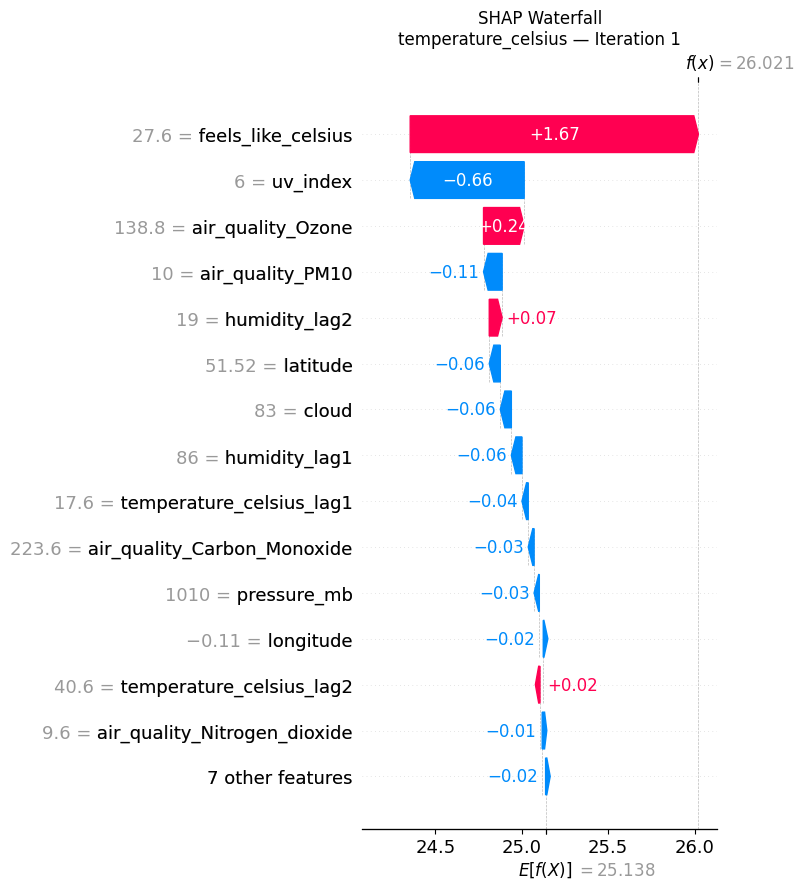

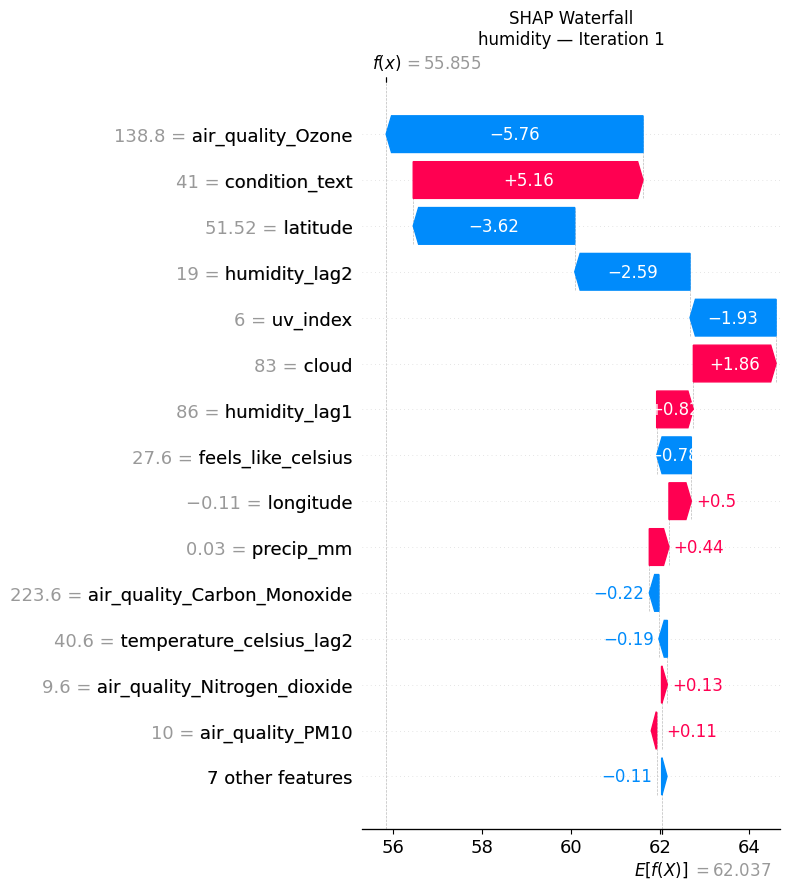

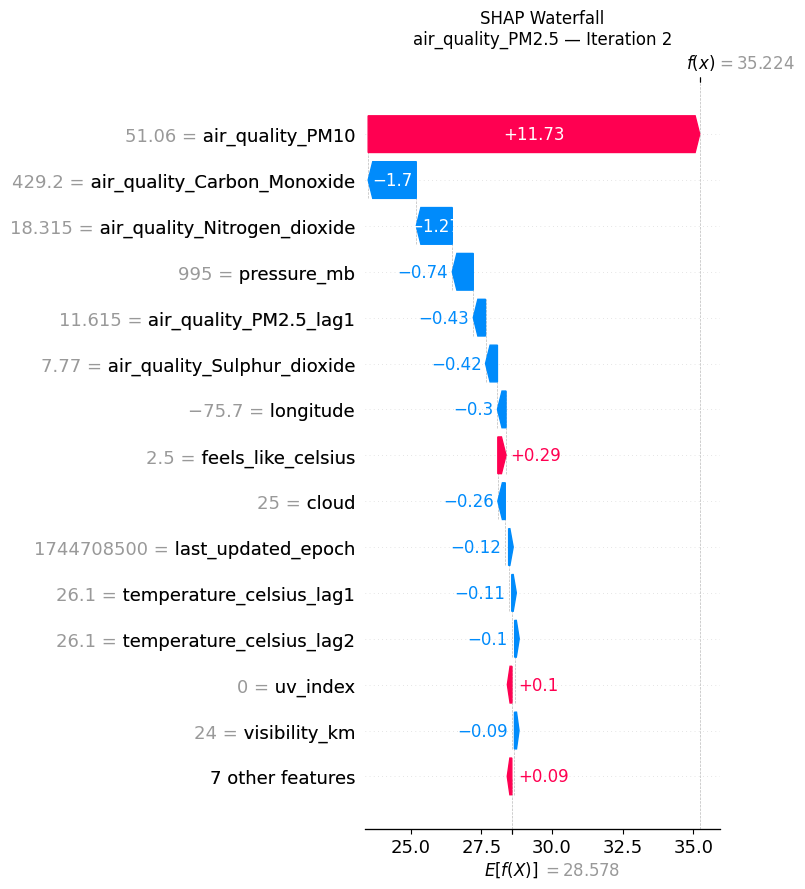

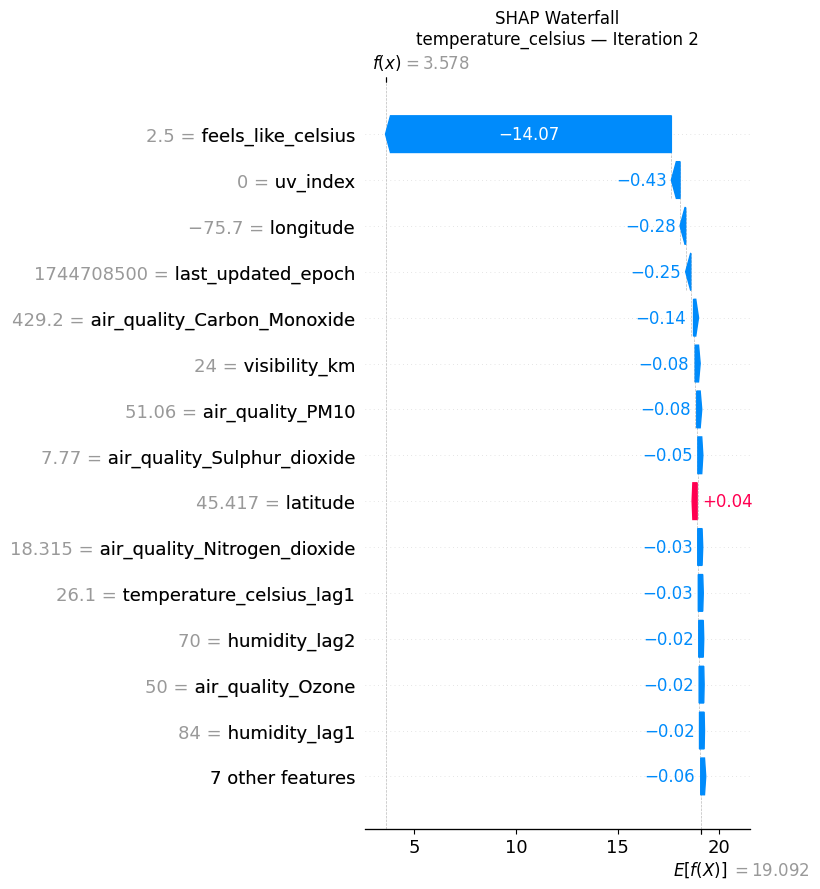

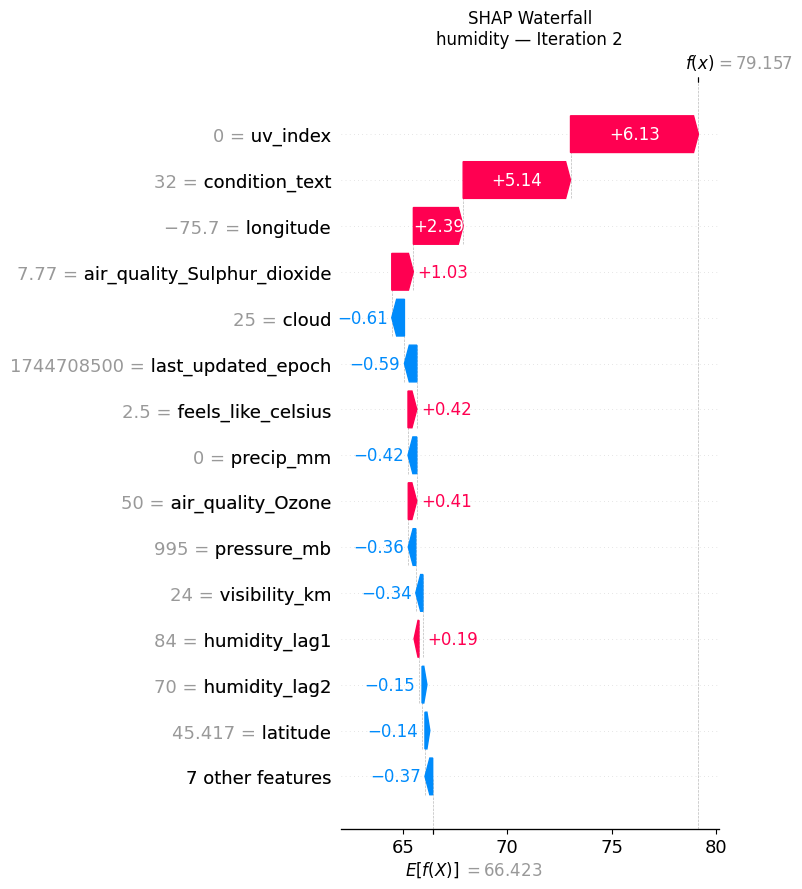

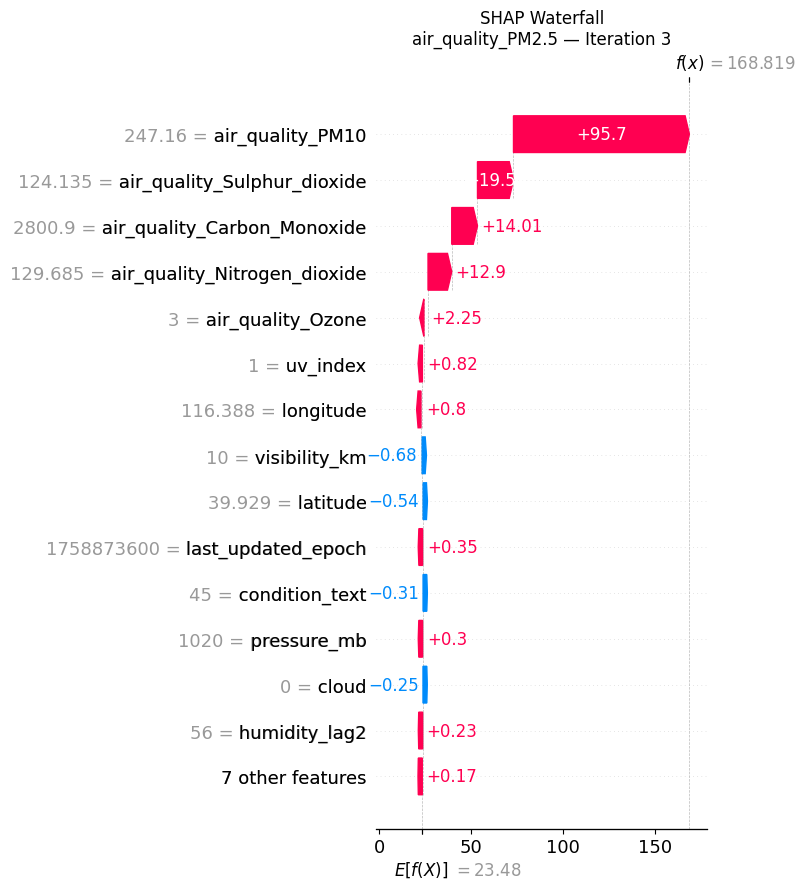

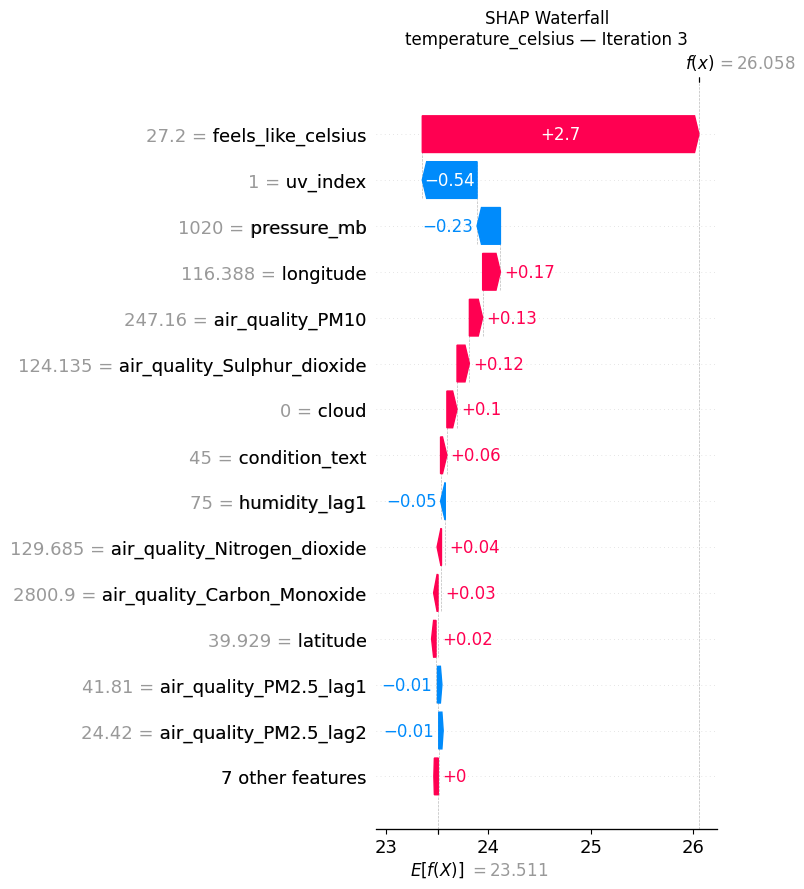

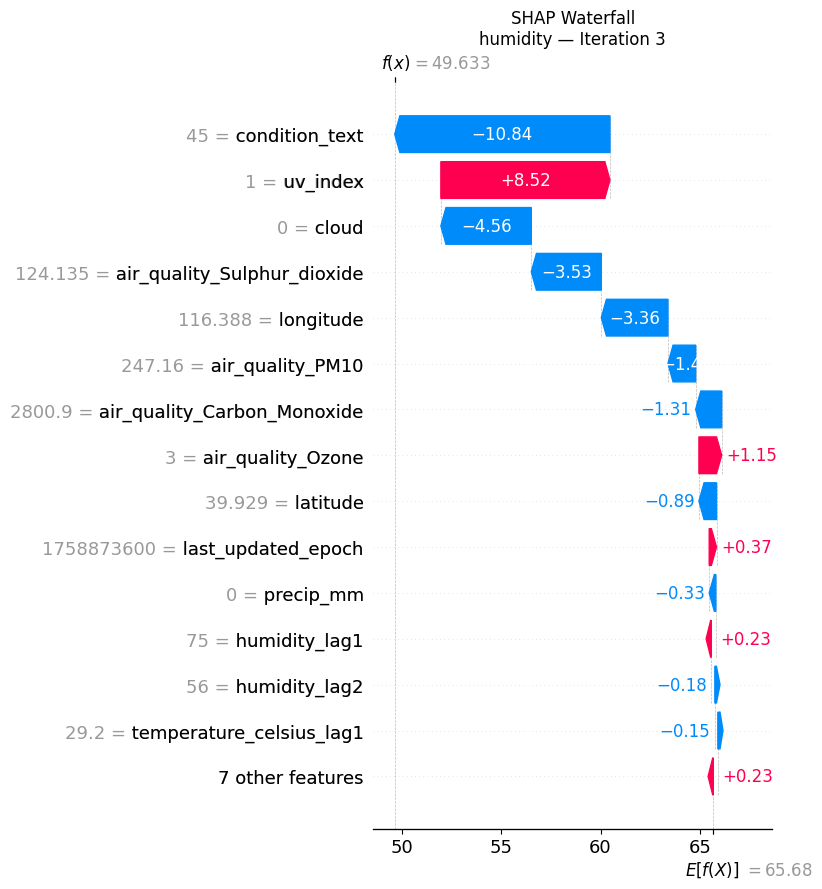

In [39]:
for iteration_name in iteration_data:

    for target in targets:

        result = shap_results[
            iteration_name
        ][target]

        explainer = result["explainer"]
        X_shap = result["X_shap"]
        shap_values = result["shap_values"]

        base_value = explainer.expected_value

        if isinstance(
            base_value,
            (list, np.ndarray)
        ):
            base_value = (
                np.asarray(base_value)
                .reshape(-1)[0]
            )

        explanation = shap.Explanation(
            values=shap_values[0],
            base_values=float(base_value),
            data=X_shap.iloc[0].values,
            feature_names=list(
                X_shap.columns
            )
        )

        shap.plots.waterfall(
            explanation,
            max_display=15,
            show=False
        )

        plt.title(
            f"SHAP Waterfall\n"
            f"{target} — {iteration_name}"
        )

        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR /
            (
                "07_SHAP_Waterfall_"
                f"{safe_name(target)}_"
                f"{safe_name(iteration_name)}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

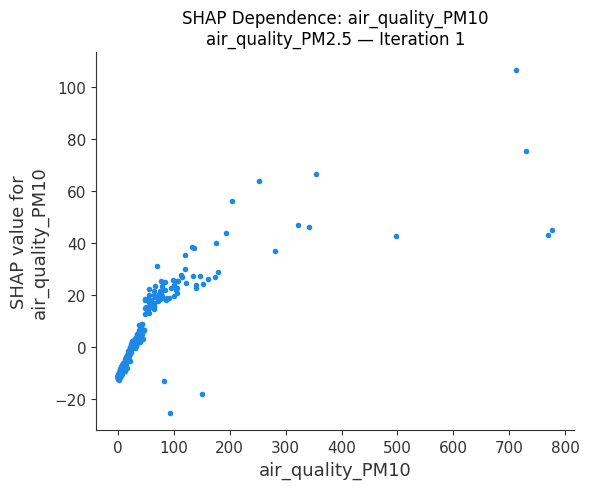

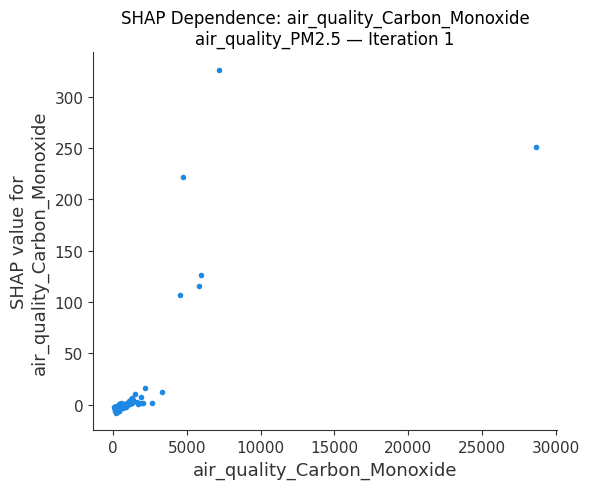

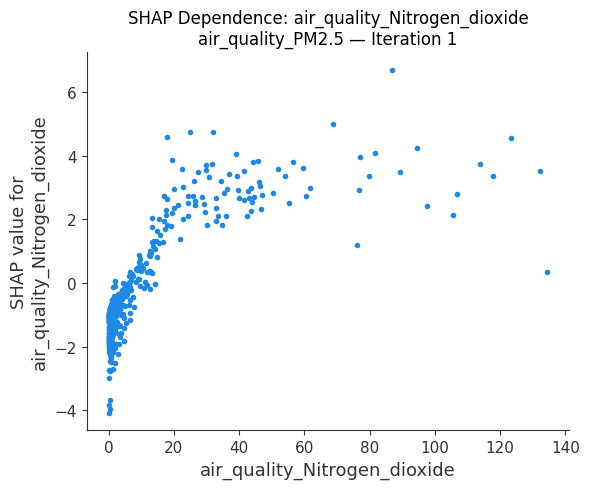

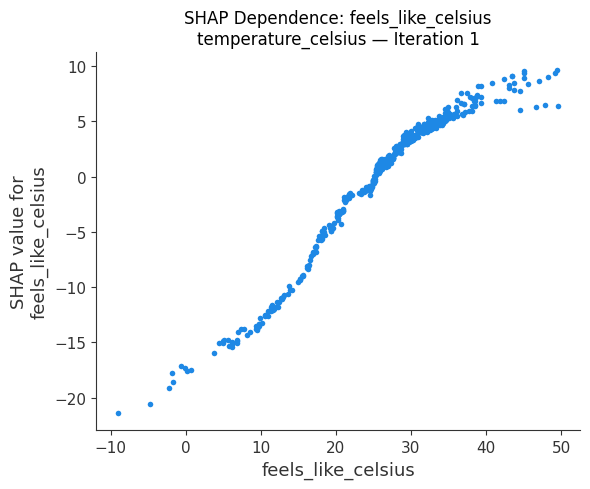

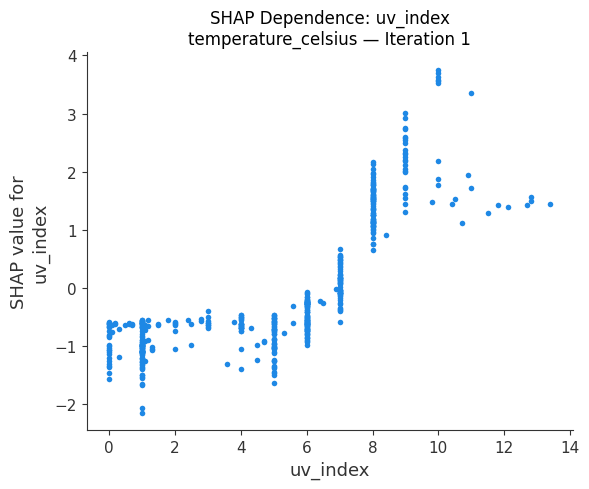

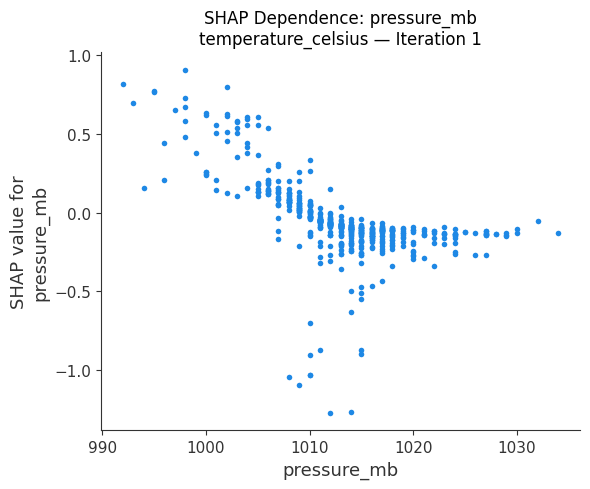

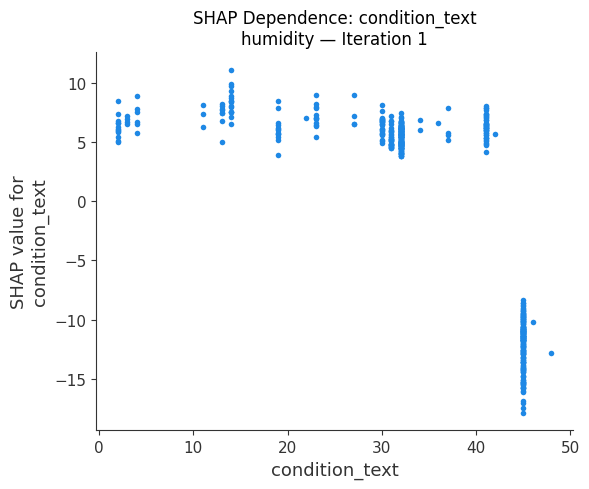

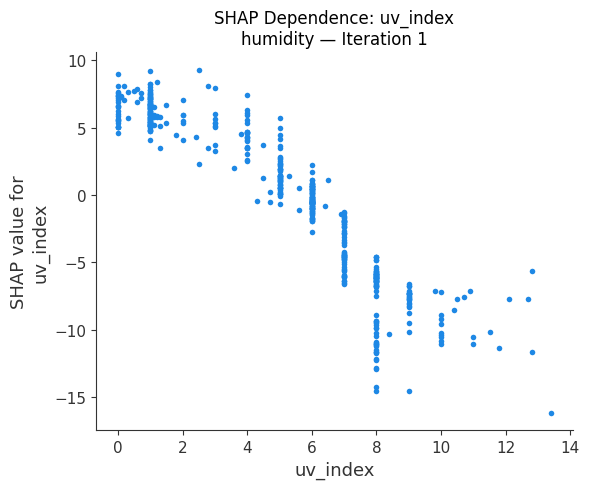

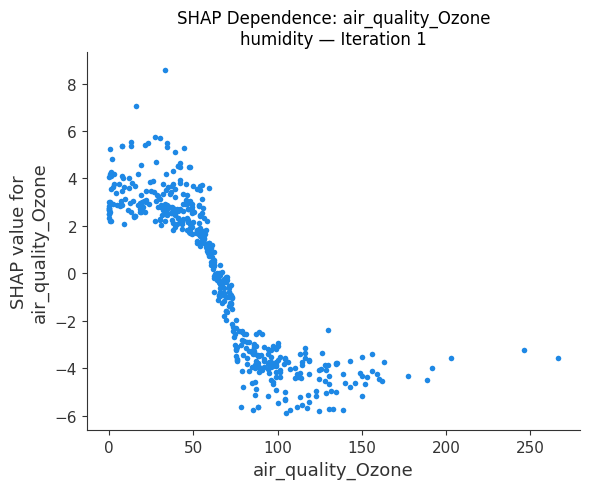

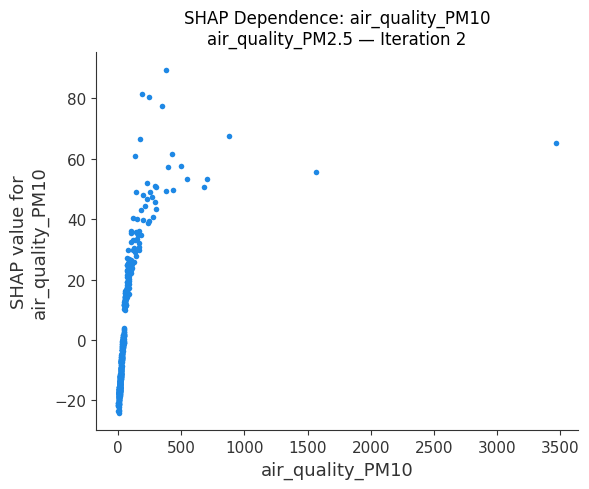

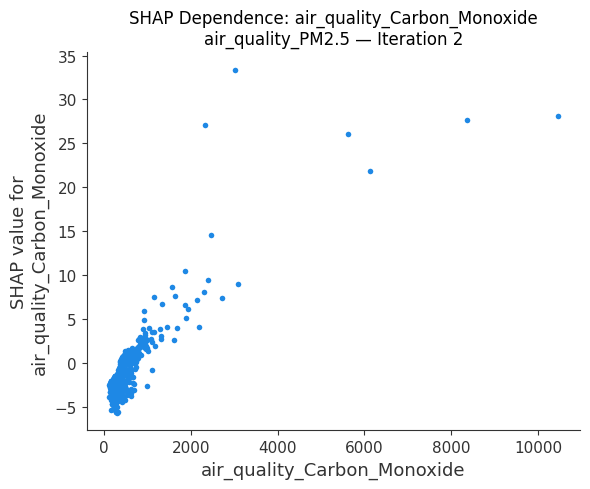

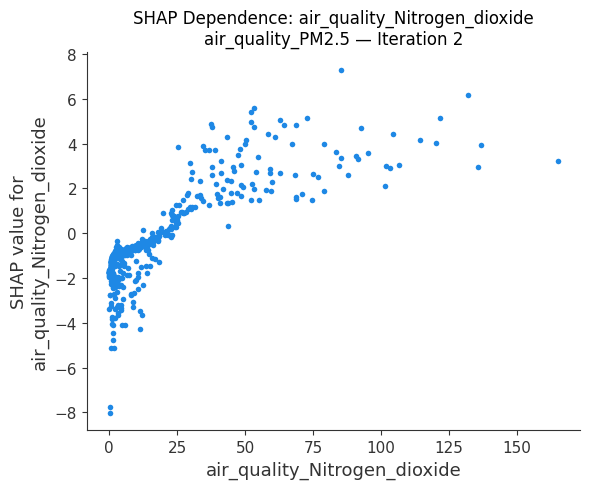

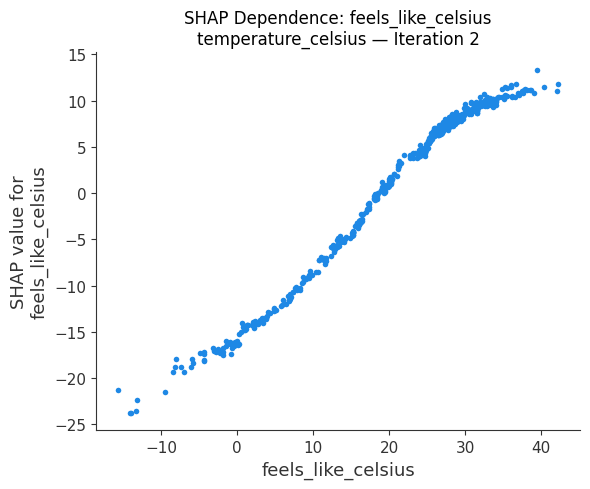

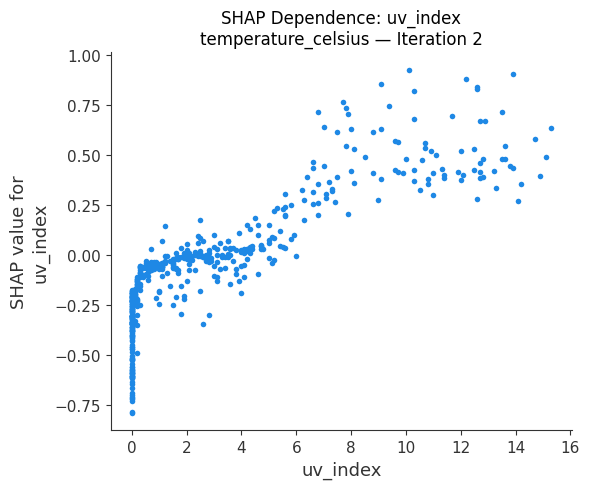

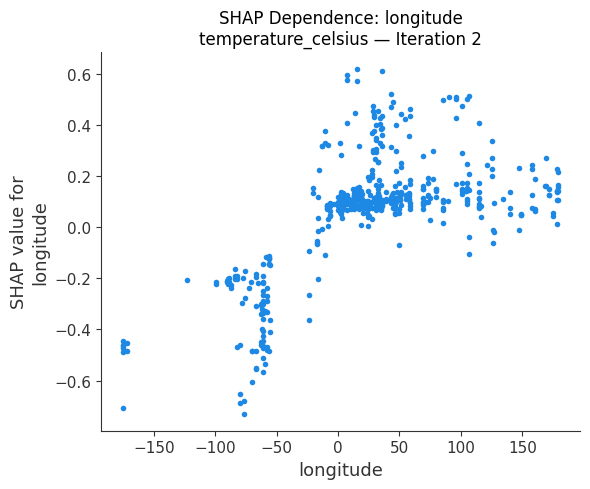

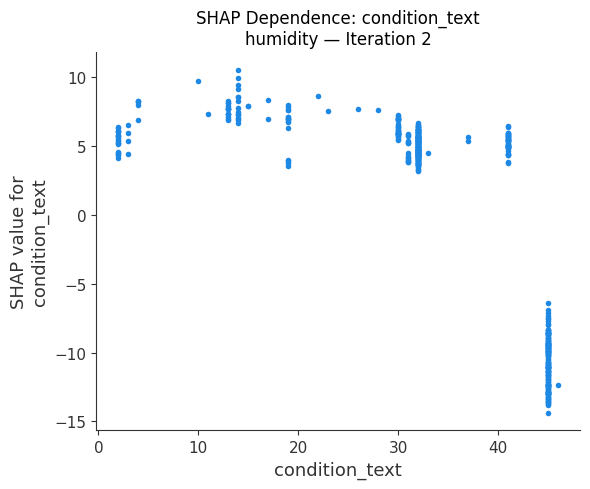

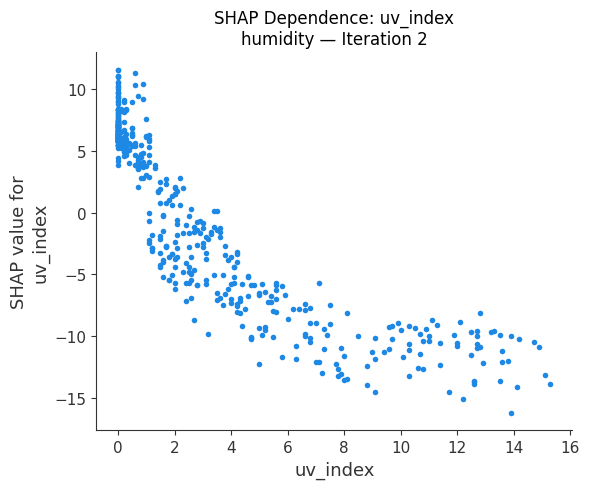

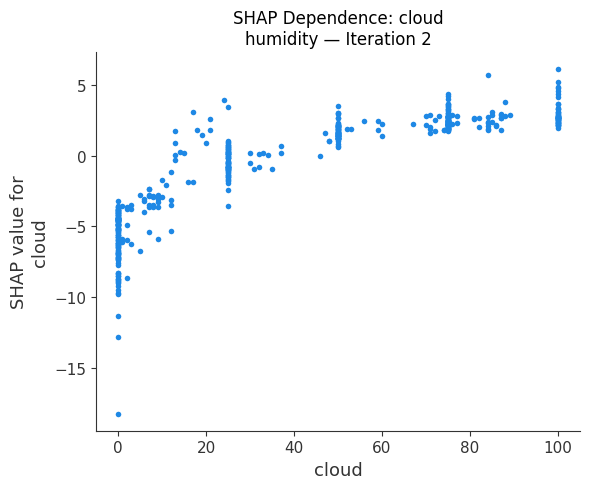

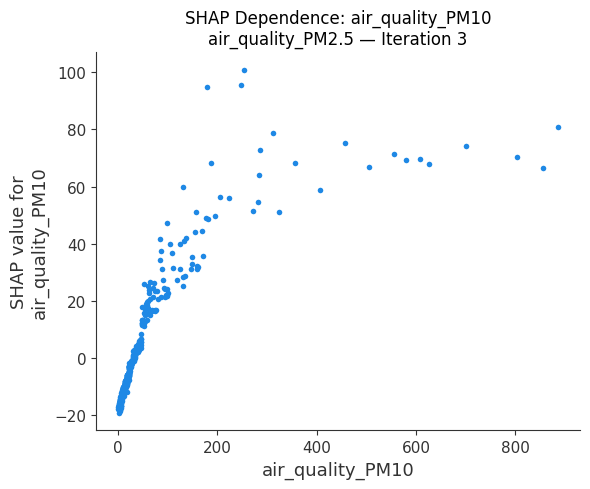

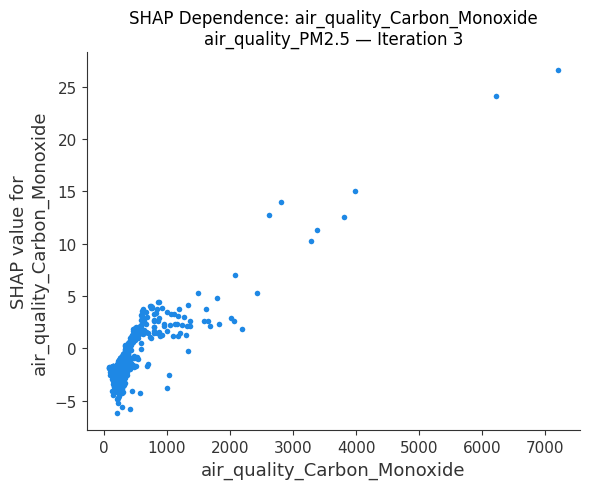

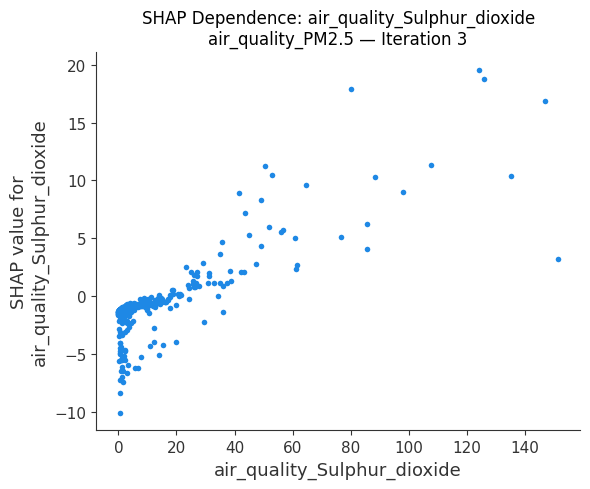

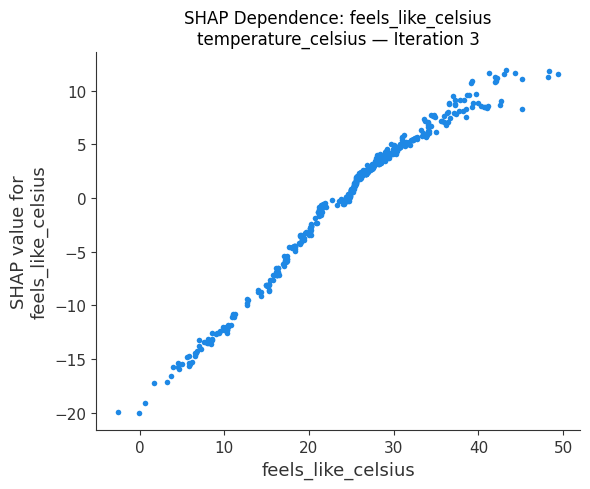

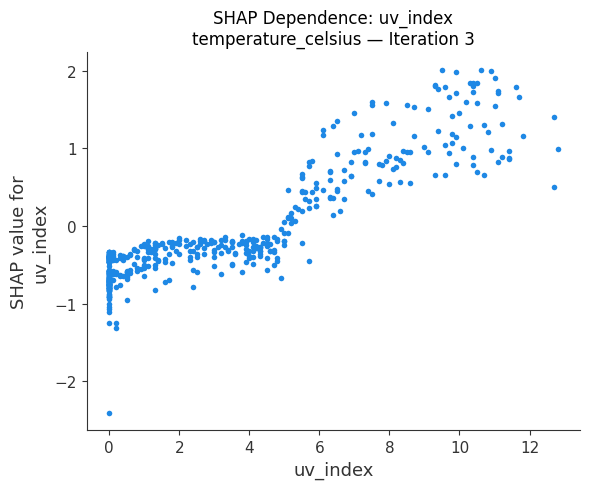

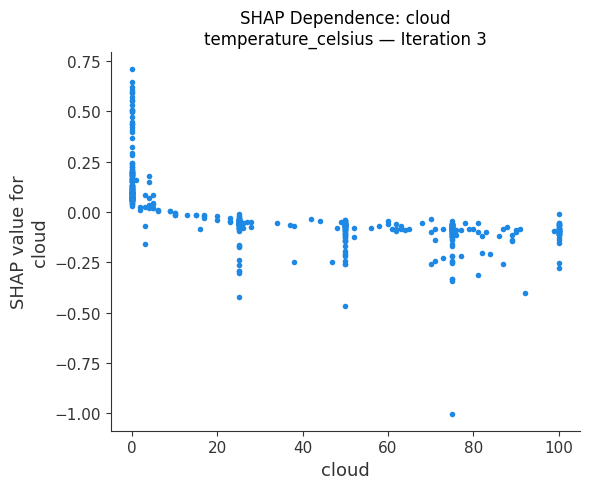

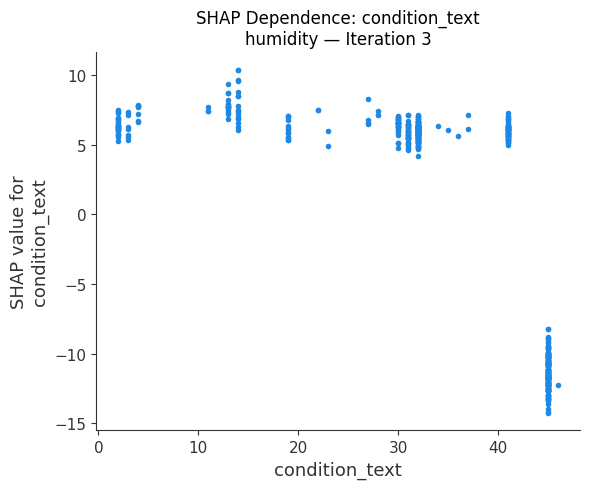

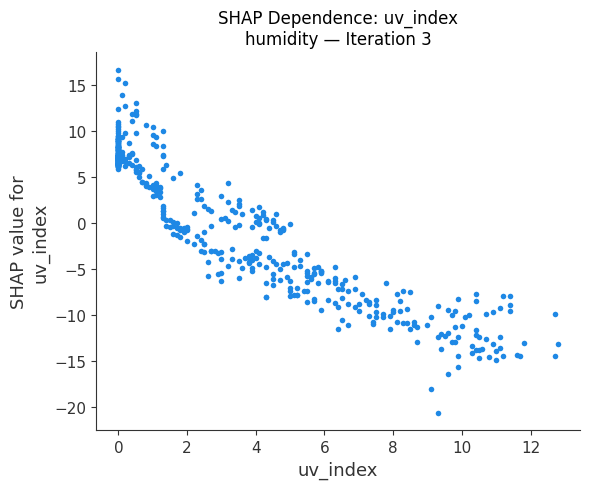

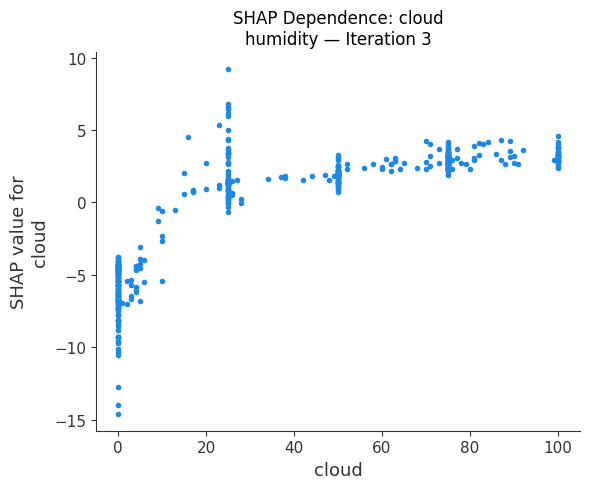

In [40]:
for iteration_name in iteration_data:

    for target in targets:

        result = shap_results[
            iteration_name
        ][target]

        X_shap = result["X_shap"]
        shap_values = result["shap_values"]

        mean_absolute_shap = (
            np.abs(shap_values)
            .mean(axis=0)
        )

        top_feature_indices = (
            np.argsort(
                mean_absolute_shap
            )[::-1][:3]
        )

        top_features = [
            X_shap.columns[index]
            for index in top_feature_indices
        ]

        for feature in top_features:

            shap.dependence_plot(
                feature,
                shap_values,
                X_shap,
                interaction_index=None,
                show=False
            )

            plt.title(
                f"SHAP Dependence: {feature}\n"
                f"{target} — {iteration_name}"
            )

            plt.tight_layout()

            plt.savefig(
                OUTPUT_DIR /
                (
                    "08_SHAP_Dependence_"
                    f"{safe_name(target)}_"
                    f"{safe_name(iteration_name)}_"
                    f"{safe_name(feature)}.png"
                ),
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()
            plt.close()

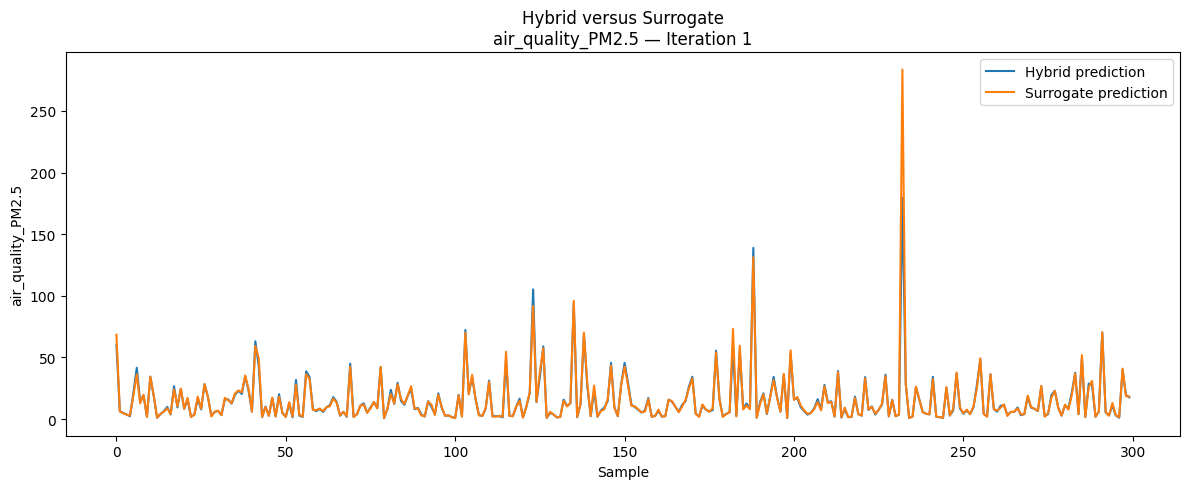

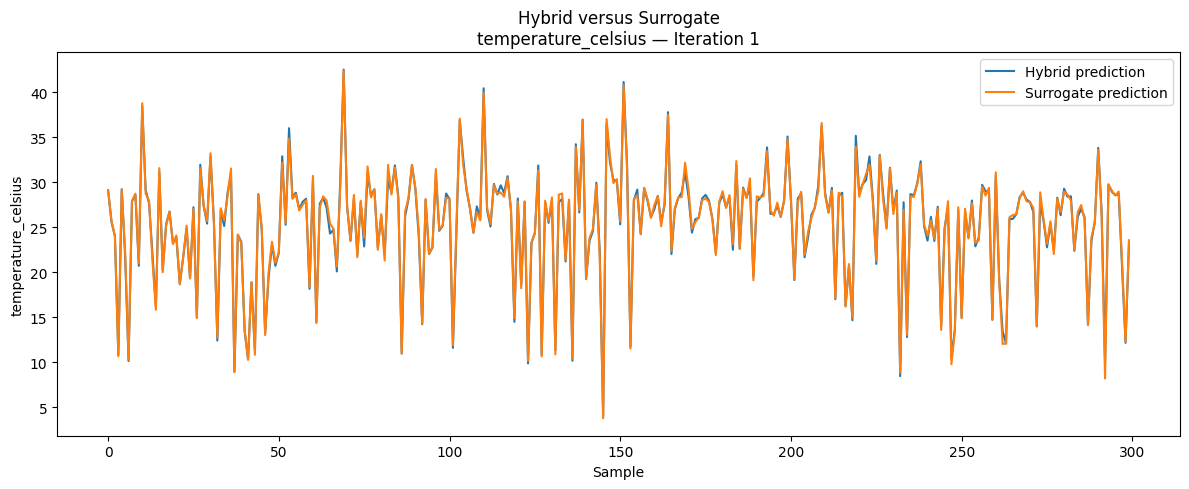

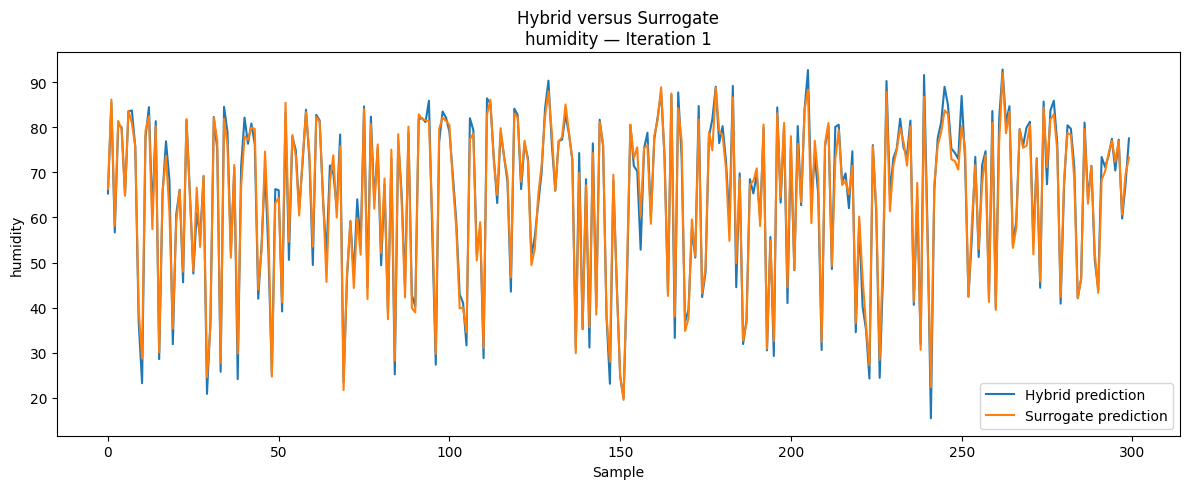

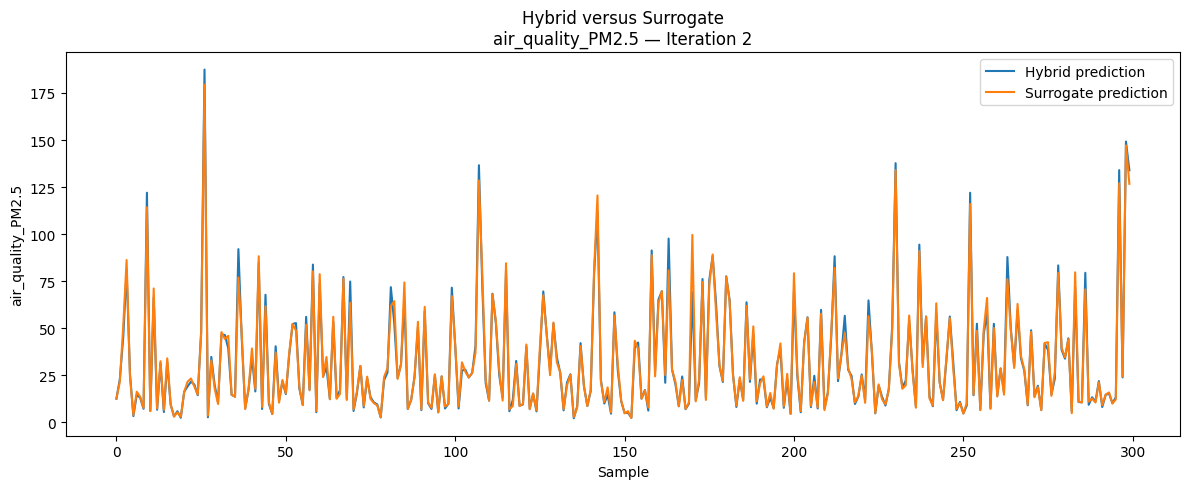

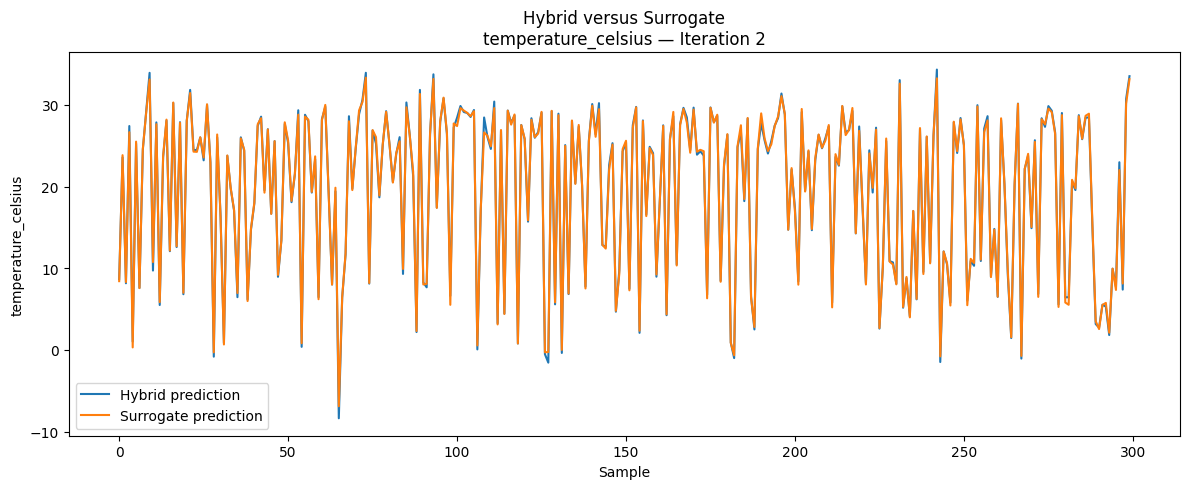

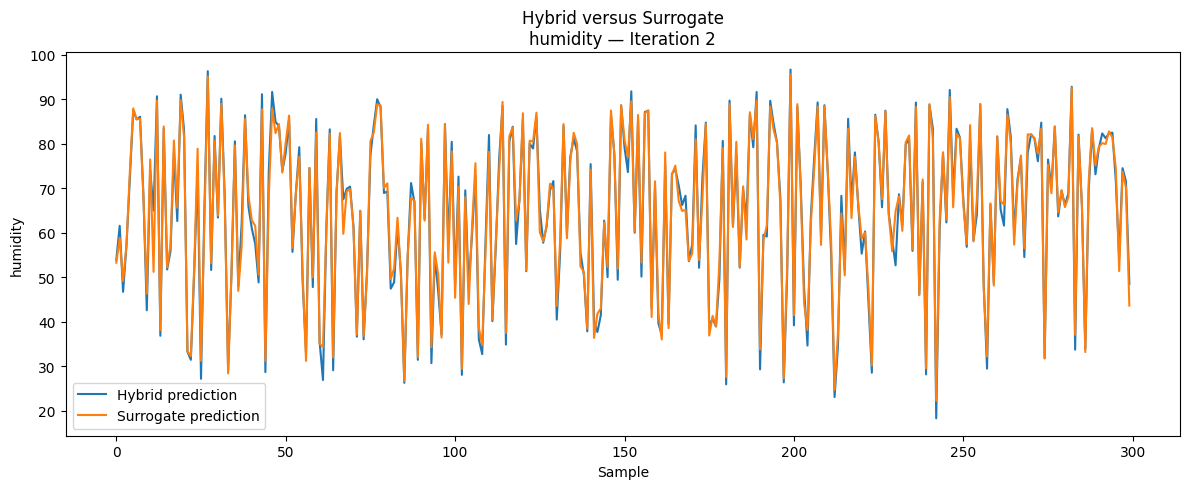

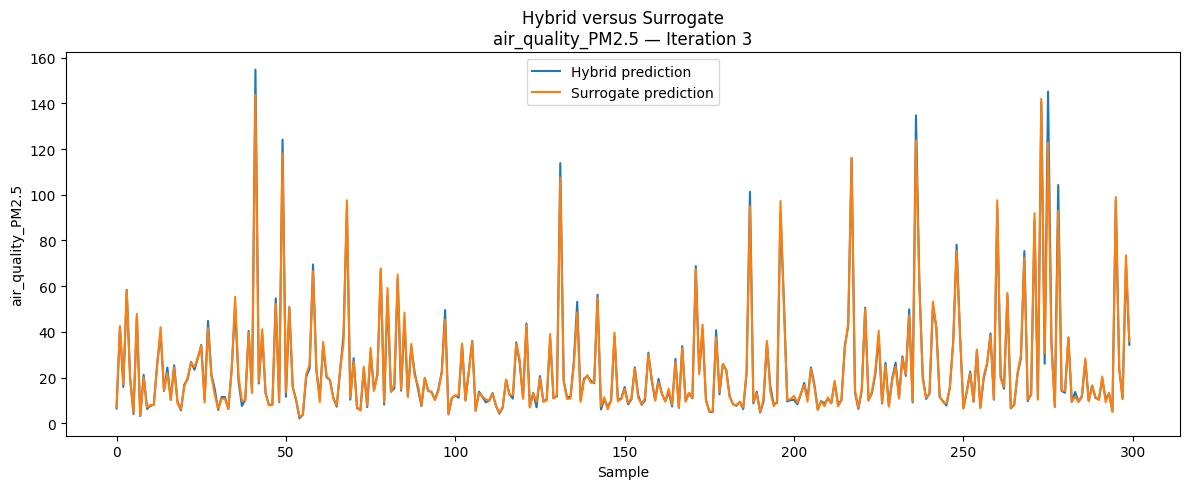

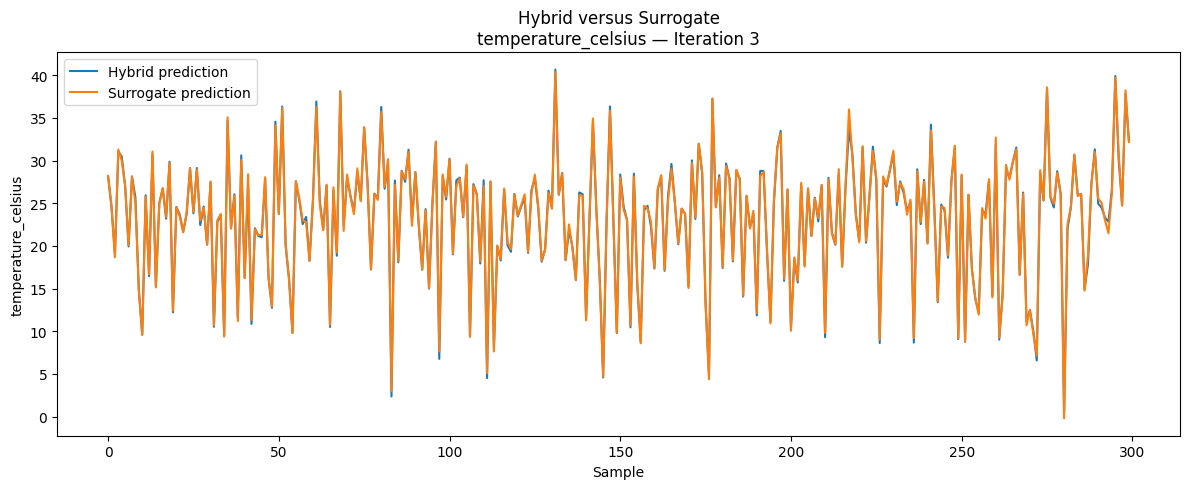

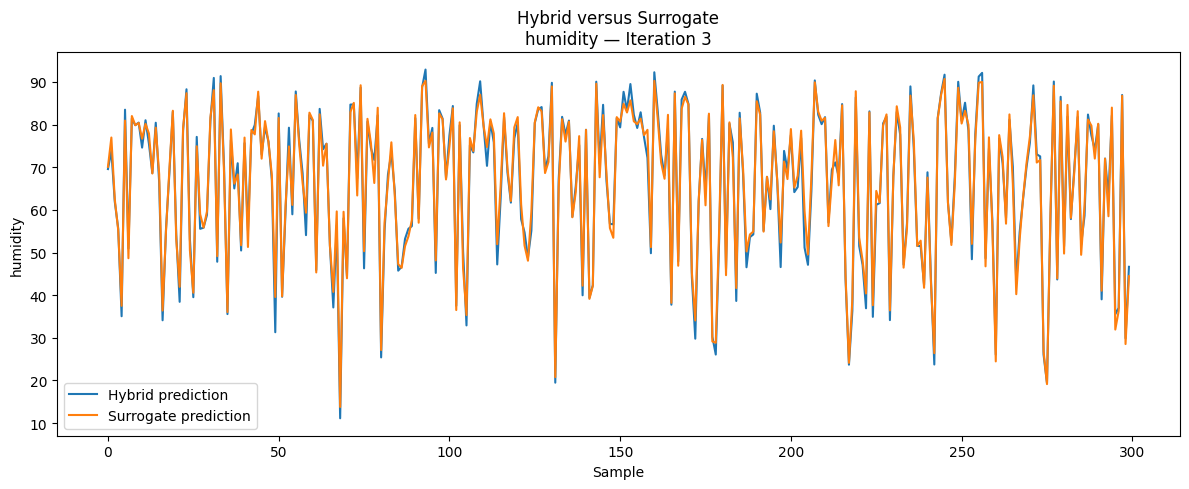

In [41]:
for iteration_name in iteration_data:

    for target in targets:

        model_info = surrogate_models[
            iteration_name
        ][target]

        y_hybrid = model_info[
            "y_hybrid"
        ]

        y_surrogate = model_info[
            "surrogate_prediction"
        ]

        display_count = min(
            300,
            len(y_hybrid)
        )

        sample_numbers = np.arange(
            display_count
        )

        plt.figure(figsize=(12, 5))

        plt.plot(
            sample_numbers,
            y_hybrid[:display_count],
            label="Hybrid prediction"
        )

        plt.plot(
            sample_numbers,
            y_surrogate[:display_count],
            label="Surrogate prediction"
        )

        plt.xlabel("Sample")
        plt.ylabel(target)

        plt.title(
            f"Hybrid versus Surrogate\n"
            f"{target} — {iteration_name}"
        )

        plt.legend()
        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR /
            (
                "09_Hybrid_vs_Surrogate_"
                f"{safe_name(target)}_"
                f"{safe_name(iteration_name)}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

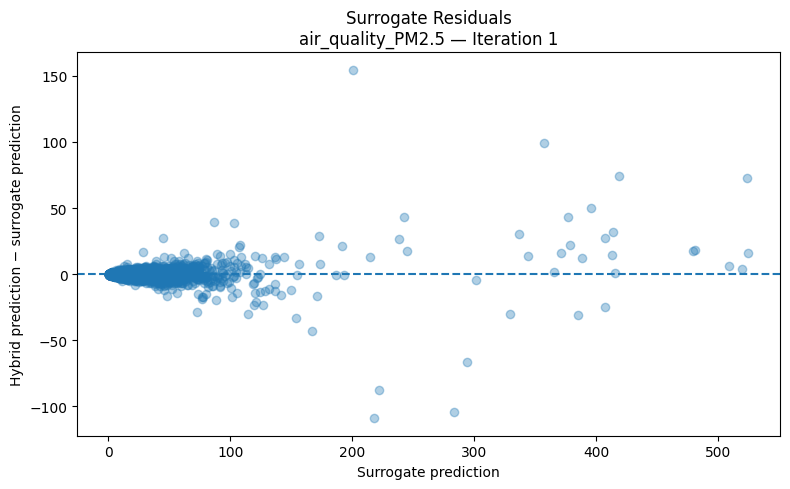

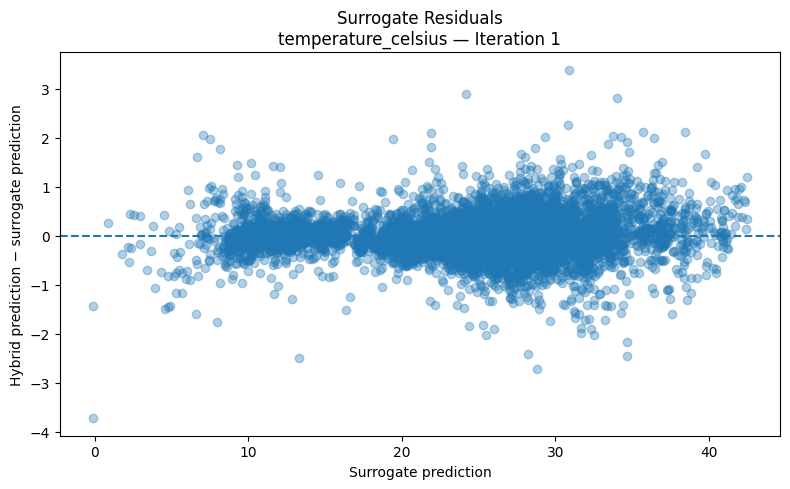

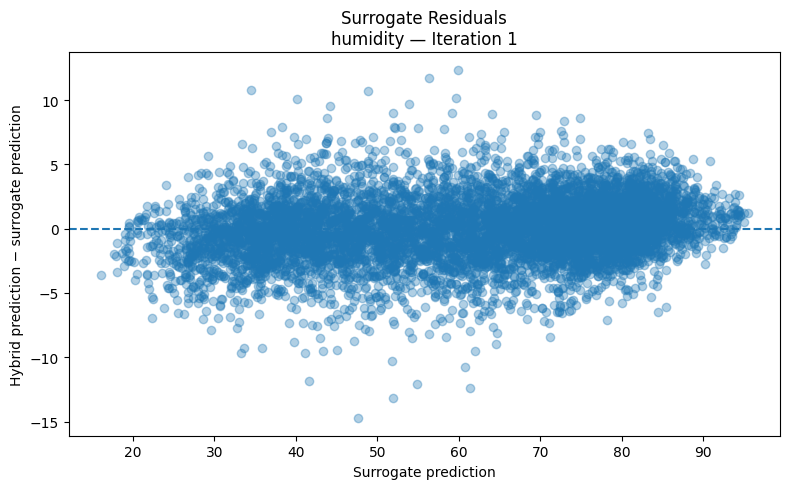

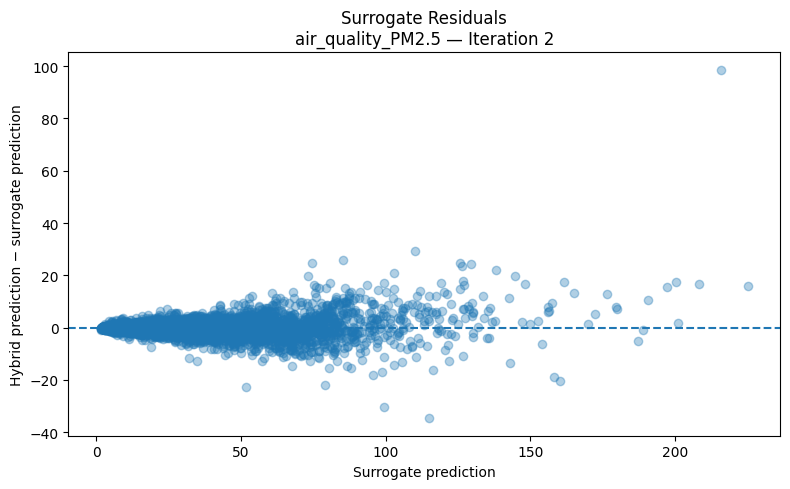

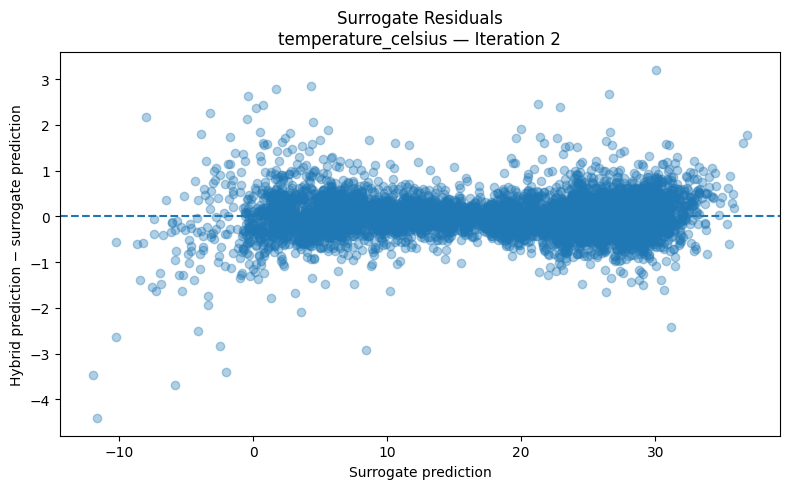

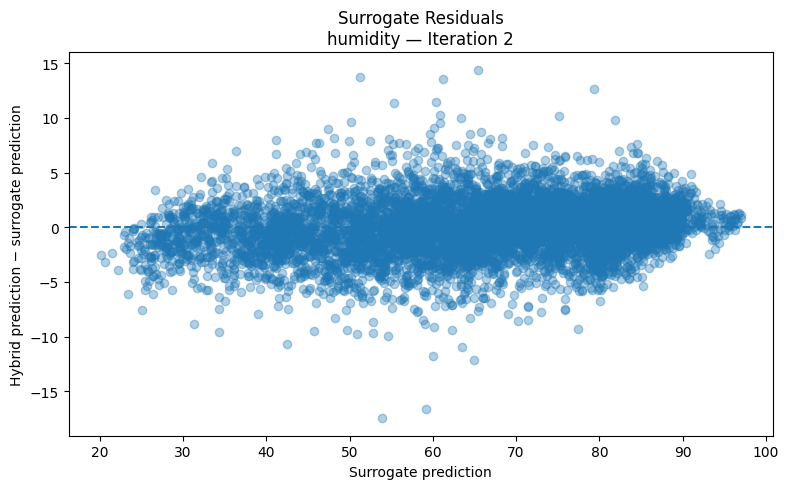

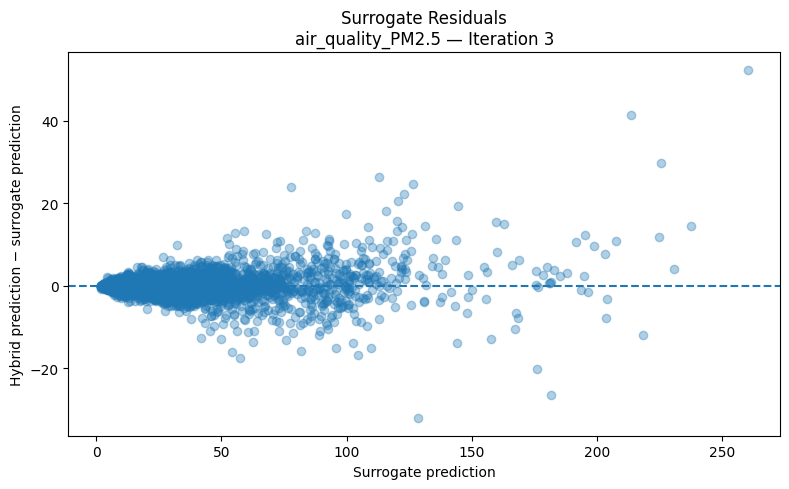

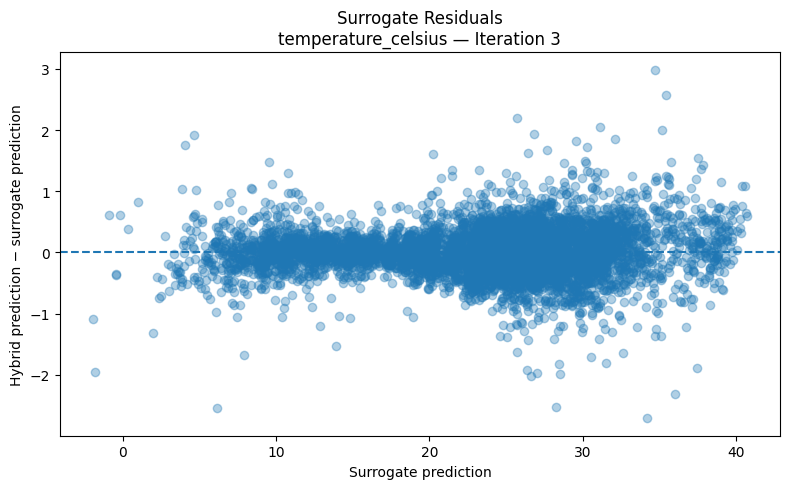

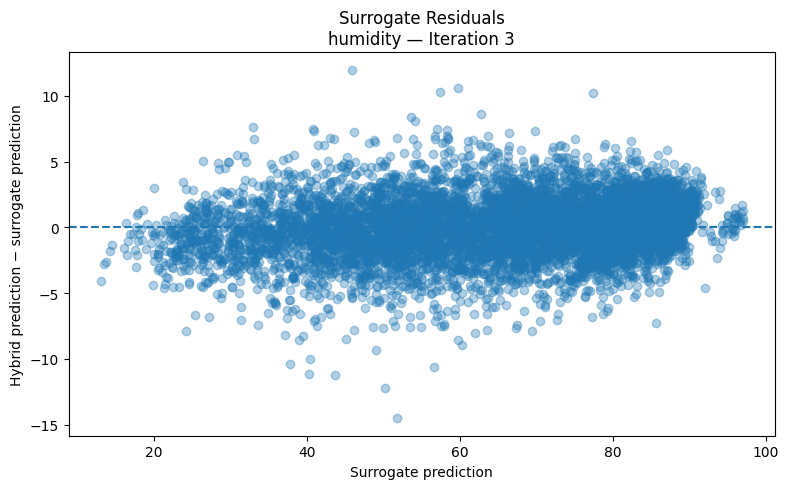

In [42]:
for iteration_name in iteration_data:

    for target in targets:

        model_info = surrogate_models[
            iteration_name
        ][target]

        y_hybrid = model_info[
            "y_hybrid"
        ]

        y_surrogate = model_info[
            "surrogate_prediction"
        ]

        residuals = (
            y_hybrid - y_surrogate
        )

        plt.figure(figsize=(8, 5))

        plt.scatter(
            y_surrogate,
            residuals,
            alpha=0.35
        )

        plt.axhline(
            y=0,
            linestyle="--"
        )

        plt.xlabel(
            "Surrogate prediction"
        )

        plt.ylabel(
            "Hybrid prediction − "
            "surrogate prediction"
        )

        plt.title(
            f"Surrogate Residuals\n"
            f"{target} — {iteration_name}"
        )

        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR /
            (
                "10_Residuals_"
                f"{safe_name(target)}_"
                f"{safe_name(iteration_name)}.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

In [43]:
final_iteration = "Iteration 3"

cross_target_rows = []

for target in targets:

    result = shap_results[
        final_iteration
    ][target]

    mean_absolute_shap = (
        np.abs(
            result["shap_values"]
        )
        .mean(axis=0)
    )

    for feature, importance in zip(
        result["X_shap"].columns,
        mean_absolute_shap
    ):
        cross_target_rows.append({
            "Target": target,
            "Feature": feature,
            "MeanAbsSHAP": importance
        })

cross_target_df = pd.DataFrame(
    cross_target_rows
)

cross_target_df.to_csv(
    OUTPUT_DIR /
    "cross_target_shap_importance.csv",
    index=False
)

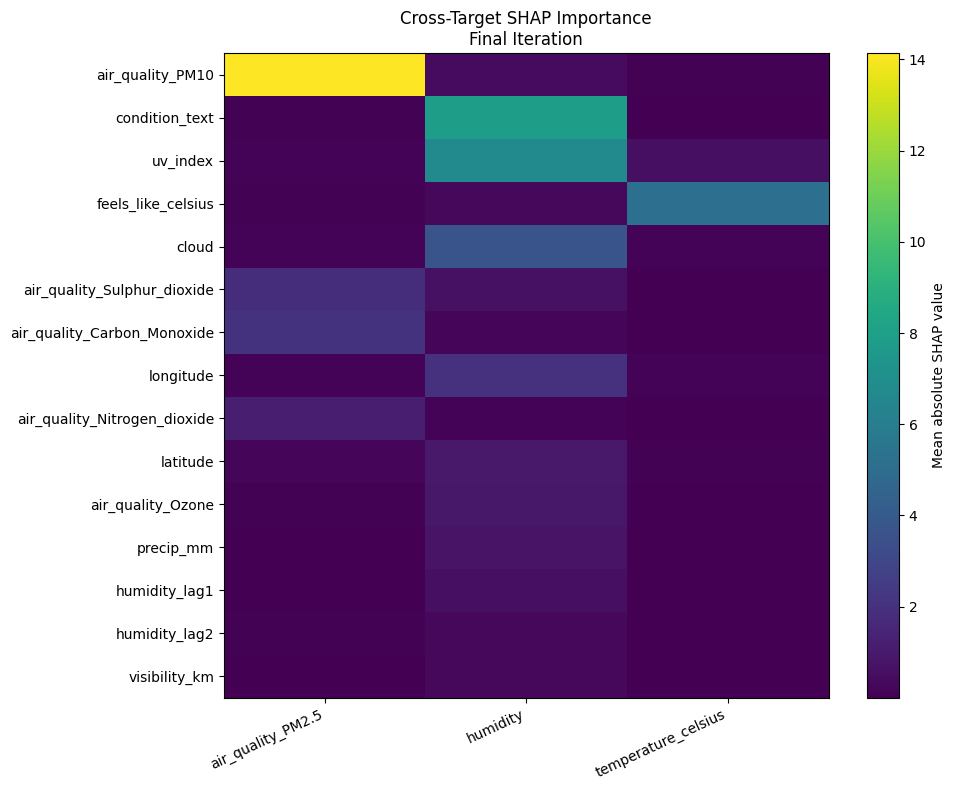

In [44]:
cross_target_matrix = (
    cross_target_df.pivot(
        index="Feature",
        columns="Target",
        values="MeanAbsSHAP"
    )
    .fillna(0)
)

top_cross_target_features = (
    cross_target_matrix
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

plot_matrix = cross_target_matrix.loc[
    top_cross_target_features
]

plt.figure(figsize=(10, 8))

image = plt.imshow(
    plot_matrix.values,
    aspect="auto"
)

plt.colorbar(
    image,
    label="Mean absolute SHAP value"
)

plt.xticks(
    range(len(plot_matrix.columns)),
    plot_matrix.columns,
    rotation=25,
    ha="right"
)

plt.yticks(
    range(len(plot_matrix.index)),
    plot_matrix.index
)

plt.title(
    "Cross-Target SHAP Importance\n"
    "Final Iteration"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "11_Cross_Target_SHAP_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [45]:
surrogate_model_path = (
    MODEL_DIR / "surrogate_models.pkl"
)

save_pickle(
    surrogate_models,
    surrogate_model_path
)

print(
    "Surrogate models saved:",
    surrogate_model_path
)

Surrogate models saved: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/saved_models/surrogate_models.pkl


In [46]:
saved_output_files = sorted(
    OUTPUT_DIR.glob("*")
)

print(
    "Number of saved output files:",
    len(saved_output_files)
)

for file_path in saved_output_files:
    print(file_path.name)

Number of saved output files: 102
01_Fidelity_air_quality_PM2.5.png
01_Fidelity_humidity.png
01_Fidelity_temperature_celsius.png
02_Feature_Importance_air_quality_PM2.5_Iteration_1.png
02_Feature_Importance_air_quality_PM2.5_Iteration_2.png
02_Feature_Importance_air_quality_PM2.5_Iteration_3.png
02_Feature_Importance_humidity_Iteration_1.png
02_Feature_Importance_humidity_Iteration_2.png
02_Feature_Importance_humidity_Iteration_3.png
02_Feature_Importance_temperature_celsius_Iteration_1.png
02_Feature_Importance_temperature_celsius_Iteration_2.png
02_Feature_Importance_temperature_celsius_Iteration_3.png
03_Feature_Monitoring_air_quality_PM2.5.png
03_Feature_Monitoring_humidity.png
03_Feature_Monitoring_temperature_celsius.png
04_Permutation_Importance_air_quality_PM2.5_Iteration_1.png
04_Permutation_Importance_air_quality_PM2.5_Iteration_2.png
04_Permutation_Importance_air_quality_PM2.5_Iteration_3.png
04_Permutation_Importance_humidity_Iteration_1.png
04_Permutation_Importance_humidi

In [47]:
zip_path = shutil.make_archive(
    str(
        PROJECT_DIR /
        "Multi_Target_XAI_Results"
    ),
    "zip",
    root_dir=OUTPUT_DIR
)

print(
    "All XAI results saved in:",
    OUTPUT_DIR
)

print(
    "ZIP file created:",
    zip_path
)

All XAI results saved in: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/xai_outputs
ZIP file created: /content/drive/MyDrive/Multi_Target_Hybrid_XAI/Multi_Target_XAI_Results.zip
